# The final picture will be a copy and paste of the following figures

Analytical coefficients (Method-B slow-manifold reduction):
  Sp*        = 4.25000
  Up*        = 0.47059
  lambda_um  = -0.029412
  alpha      = -0.0294 (paper's alpha)
  beta      = 3.0008 (paper's beta)
  gamma      = 8.5395   (paper's gamma)
  zeta      = -4.2500 (paper's zeta)
  eta      = 0.2353 (paper's eta)



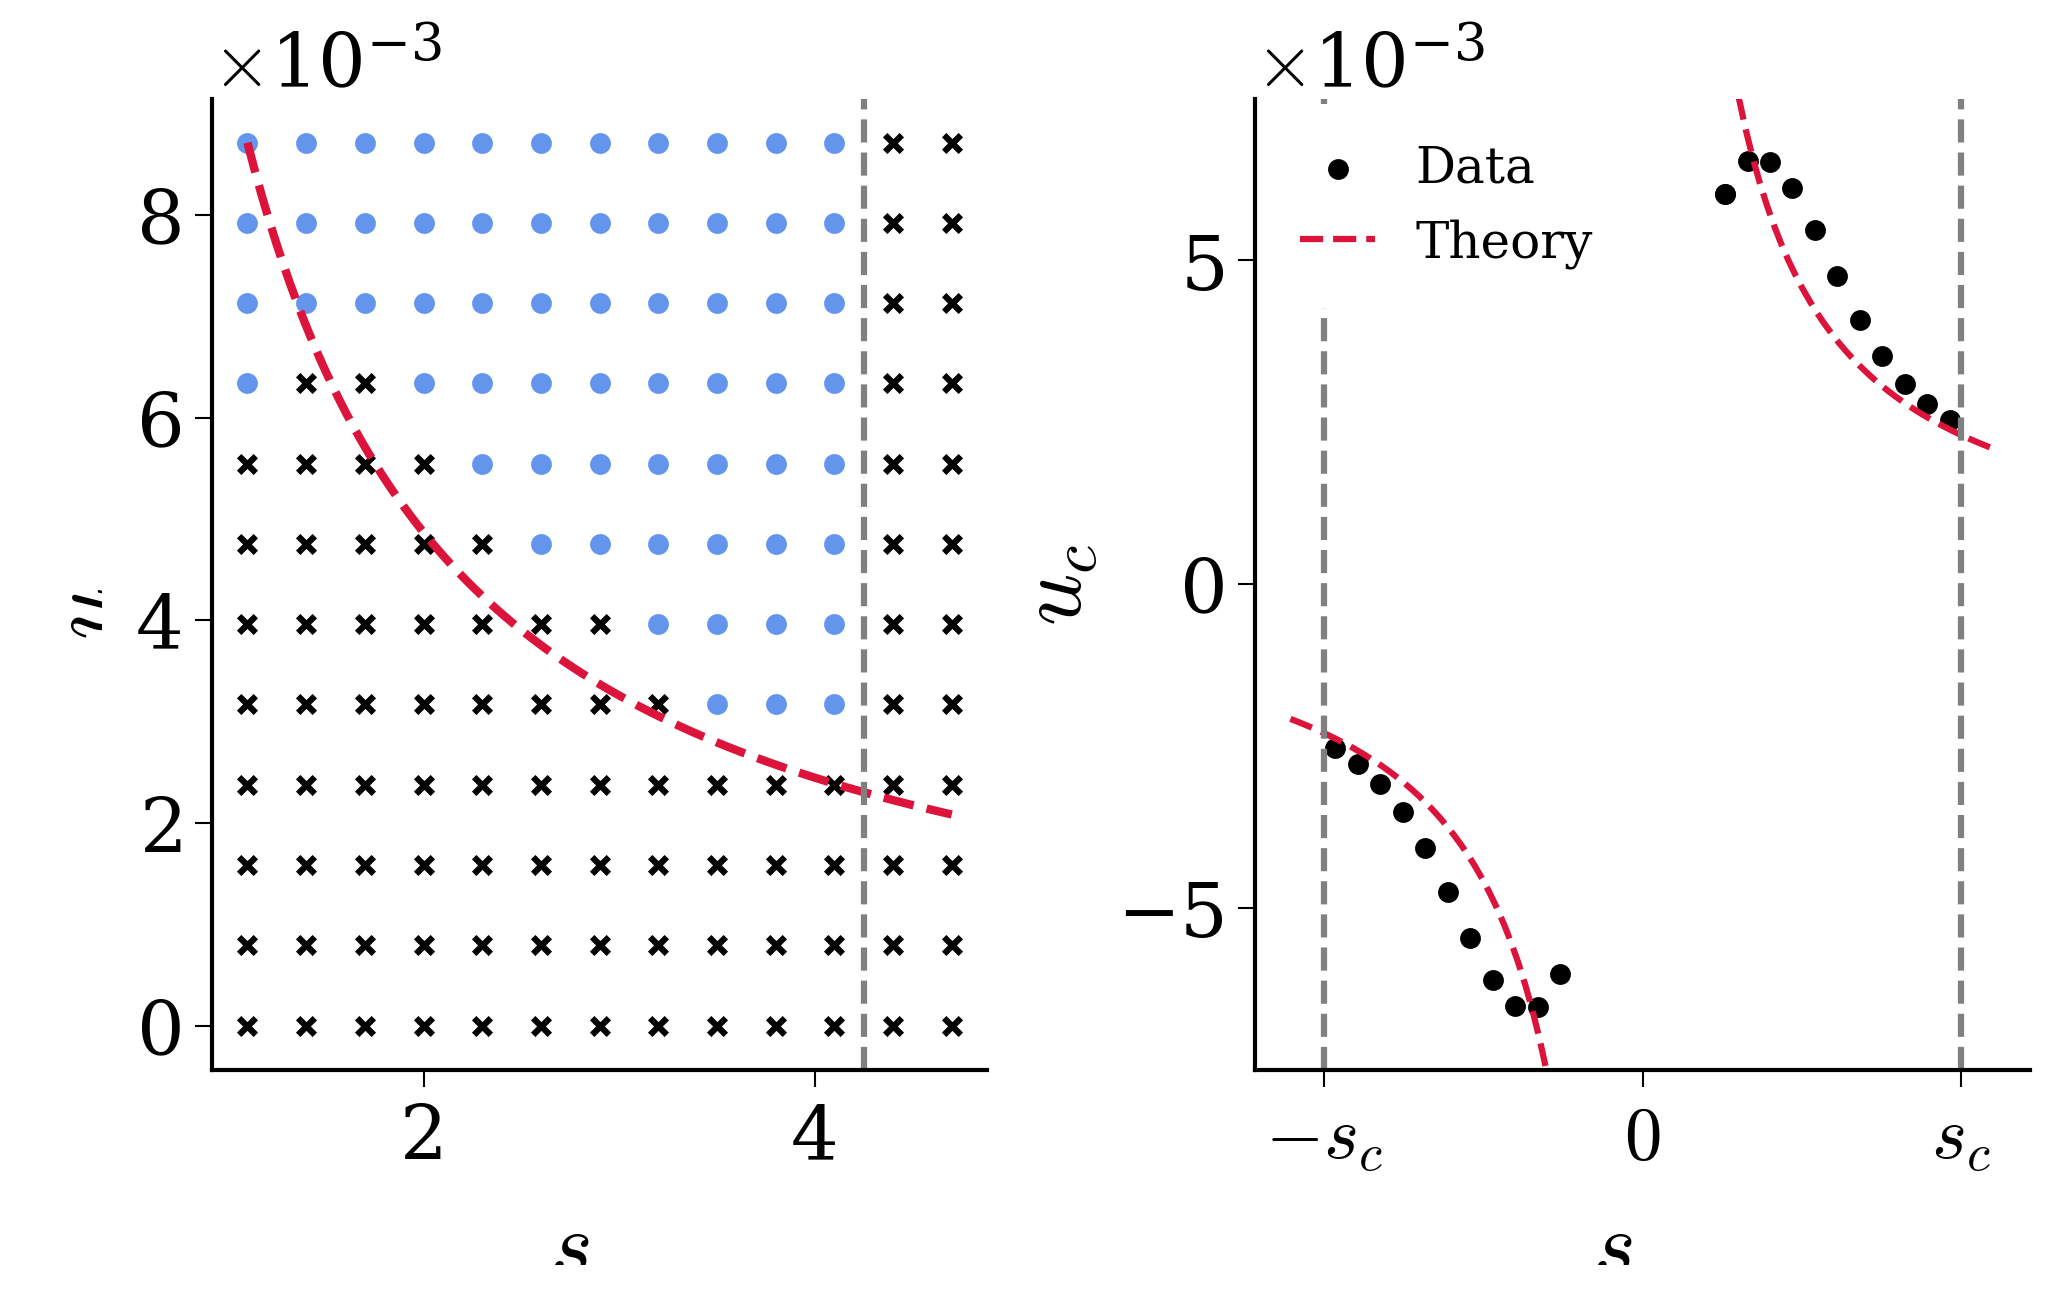

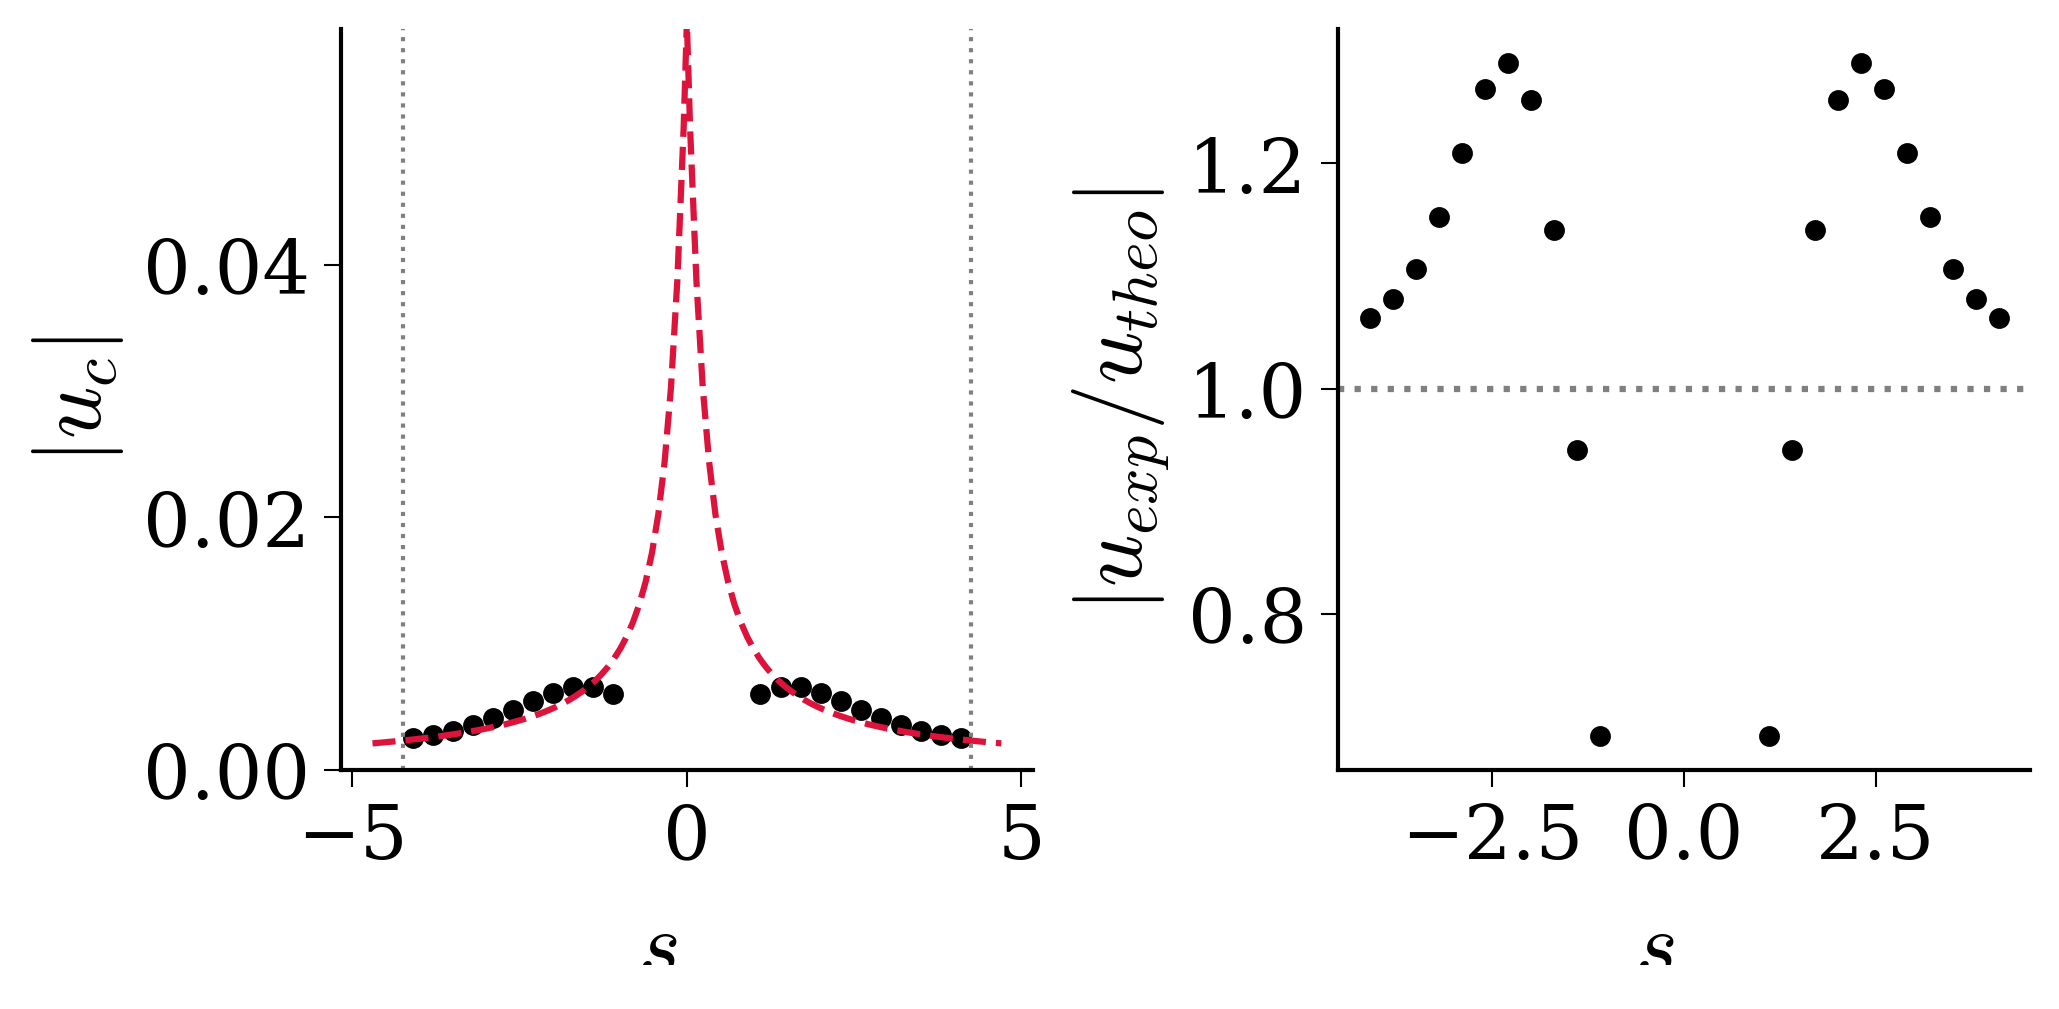

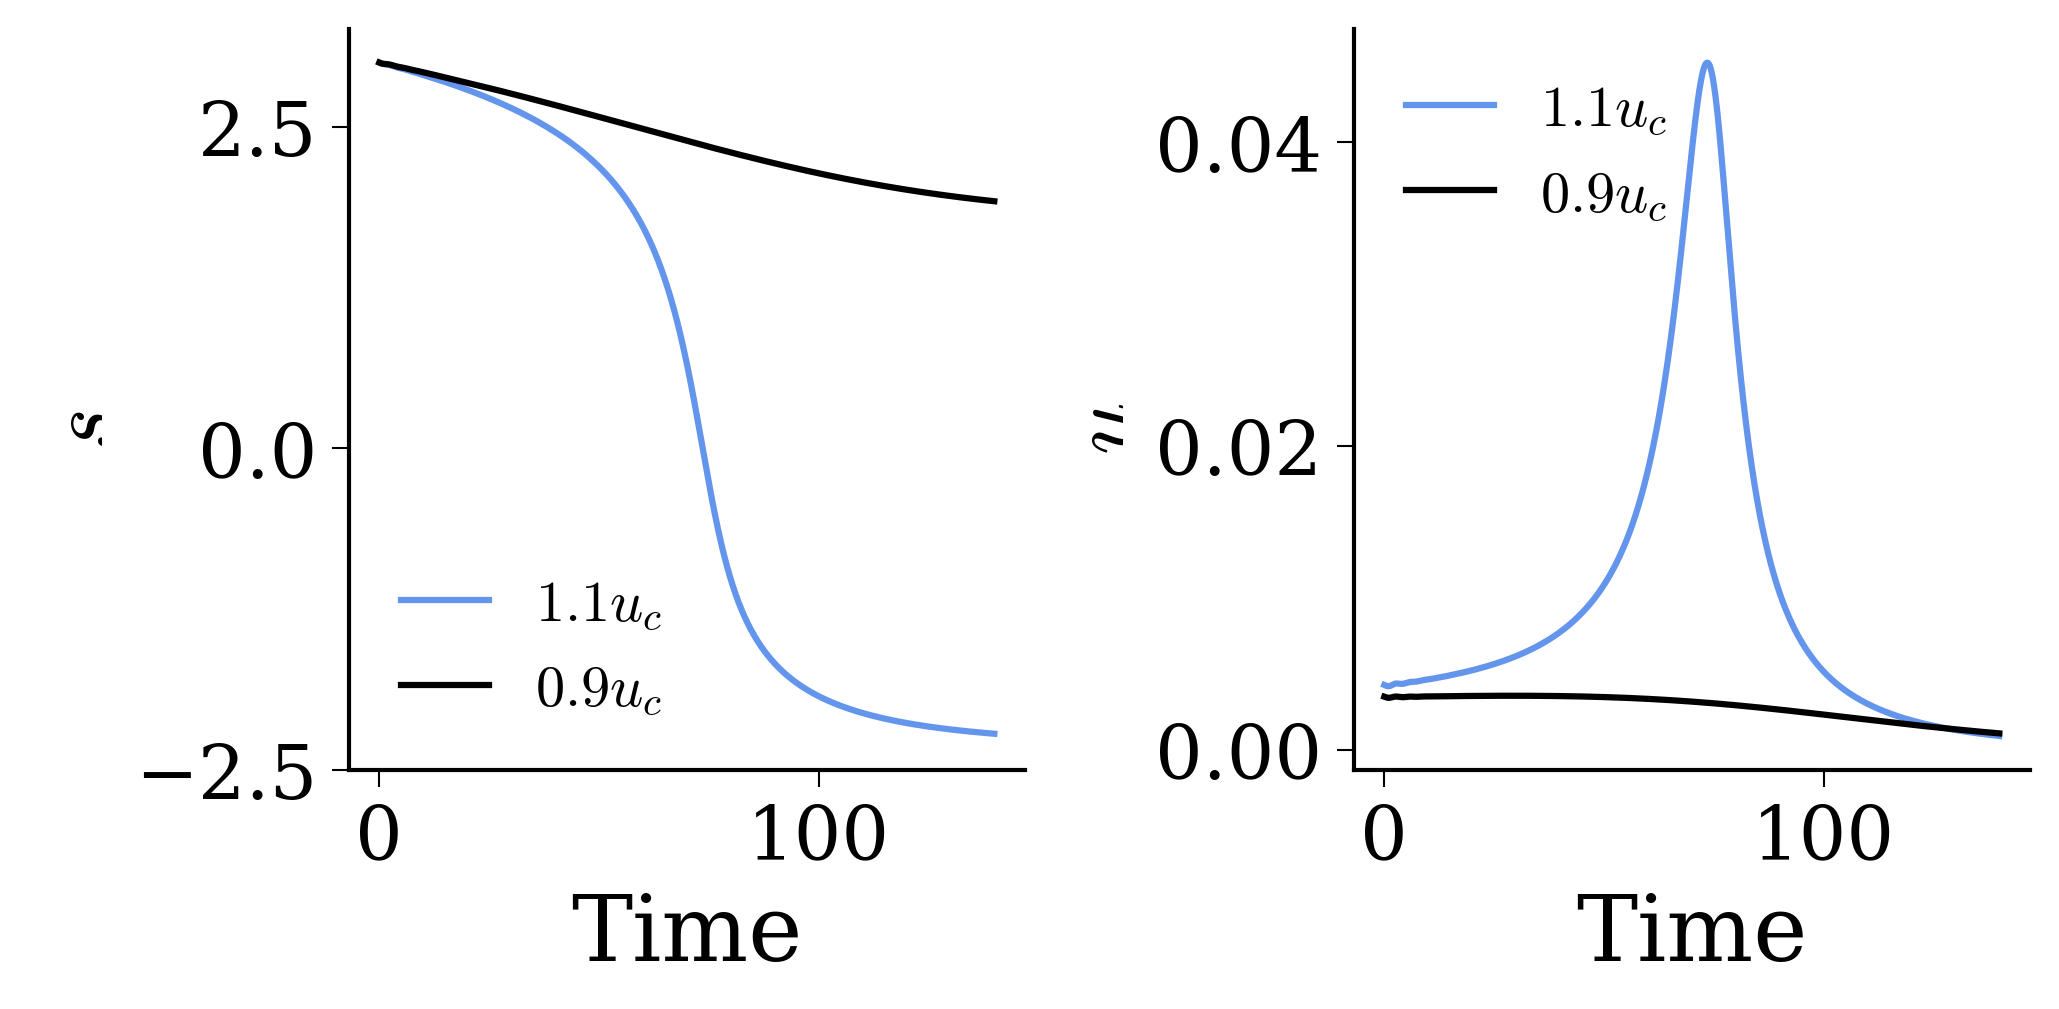

In [6]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')

def parameters(a: float, b: float, c: float, d: float) -> dict:

    s_plus = (b*d**2+c*a**2)/(d*c*a)
    u_plus = c*a**2/(c*a**2+b*d**2)

    #coefficients computed as described in appendix C after substitution

    lambda4 = -b-a/s_plus -d*(1-2*u_plus) + c*s_plus**2*(2*u_plus - 3*u_plus**2)

    dup_sp = -a*(1-u_plus)/s_plus**2 + 2*c*s_plus*(u_plus**2 - u_plus**3)
    dup_um =(2*d + c*s_plus**2*(2 - 6*u_plus))/2

    detA = (lambda4*u_plus - s_plus*dup_sp)

    par = a/s_plus**2 + 2*c*s_plus*(2*u_plus -3*u_plus**2)

    alpha = lambda4 
    beta = -lambda4*par/(detA) + dup_sp*(c*s_plus**2*(2-6*u_plus) +2*d)/detA
    gamma = -c*s_plus**2 + par*s_plus*dup_um/detA - u_plus*dup_um*(c*s_plus**2*(2-6*u_plus)+2*d)/(detA)

    zeta = -d*(s_plus)
    eta = (lambda4*a/(s_plus**2) - d*dup_sp)/detA


    return dict(s_plus=s_plus, u_plus=u_plus, lambda_u=lambda4, alpha=alpha, beta=beta, gamma=gamma, zeta=zeta, eta=eta)

def rhs(state: np.ndarray, a: float, b: float, c: float, d: float) -> np.ndarray:
    """
    Right-hand side of the reduced 4D system (S+, S-, U+, U-).
    Guarded against S+ -> 0 or u_+ -> {0, 1} in the physical domain
    (the trajectories we care about stay away from these boundaries).
    """
    Sp, Sm, Up, Um = state
    Sp_safe = max(Sp, 1e-12)

    dSp = a - d * (Sp * Up + Sm * Um)
    dSm = a / Sp_safe * Sm - d * (Sp * Um + Sm * Up)
    dUp = (
        a * (1.0 - Up) / Sp_safe
        - b * Up
        + c * Sp * Sp * (Up * Up * (1.0 - Up) + Um * Um * (1.0 - 3.0 * Up))
        - d * ((1.0 - Up) * Up - Um * Um)
    )
    dUm = Um * (
        -a / Sp_safe - b - d * (1.0 - 2.0 * Up)
        + c * Sp * Sp * (Up * (2.0 - 3.0 * Up) - Um * Um)
    )
    return np.array([dSp, dSm, dUp, dUm])

def rk4_step(state: np.ndarray, h: float,
             a: float, b: float, c: float, d: float) -> np.ndarray:
    k1 = rhs(state, a, b, c, d)
    k2 = rhs(state + 0.5 * h * k1, a, b, c, d)
    k3 = rhs(state + 0.5 * h * k2, a, b, c, d)
    k4 = rhs(state + h * k3, a, b, c, d)
    return state + h * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0

def integrate_track(state0: np.ndarray, T: float, h: float,
                    a: float, b: float, c: float, d: float
                    ) -> tuple[np.ndarray, float]:
    """
    Integrate to final time T. Returns (final state, peak |Um| along the
    trajectory). The peak |Um| is our diagnostic for whether the cubic
    instability fired.
    """
    state = state0.copy()
    n = int(np.ceil(T / h))
    peak_Um = abs(state[3])
    for _ in range(n):
        state = rk4_step(state, h, a, b, c, d)
        if abs(state[3]) > peak_Um:
            peak_Um = abs(state[3])
    return state, peak_Um

def transitions(u0: float, s0: float, coeffs: dict,
                a: float, b: float, c: float, d: float,
                T_int: float = 120.0, h: float = 0.04) -> bool:
    """
    Test whether starting at (S+*, s0, U+*, u0) leads to s_- crossing
    zero to the opposite side. Physical definition of a transition:
    the volumes swap sign.
    Applied only for |s0| sufficiently large (see main()).
    """
    Sp = coeffs["s_plus"]
    Up = coeffs["u_plus"]
    state0 = np.array([Sp, s0, Up, u0])
    final, _ = integrate_track(state0, T_int, h, a, b, c, d)
    Sm_final = final[1]
    # sign flip of s_-
    return np.sign(Sm_final) != np.sign(s0)

def integrate_full(state0: np.ndarray, T: float, h: float,
                   a: float, b: float, c: float, d: float
                   ) -> tuple[np.ndarray, np.ndarray]:
    """
    Integrate to final time T. Returns (times, states) with states of
    shape (n+1, 4). Used to plot trajectories for diagnostic panels.
    """
    n = int(np.ceil(T / h))
    times = np.linspace(0.0, n * h, n + 1)
    states = np.zeros((n + 1, 4))
    state = state0.copy()
    states[0] = state
    for i in range(n):
        state = rk4_step(state, h, a, b, c, d)
        states[i + 1] = state
    return times, states


def du_escape(s_arr: np.ndarray, coeffs: dict) -> np.ndarray:
    """
    Analytical escape threshold |Delta u_-| as a function of s_-.
    Uses the rationalised form to remain numerically stable at s_- = 0.
    return both brances of the solution
    """
    lam = coeffs["lambda_u"]
    beta = coeffs["beta"]
    gamma = coeffs["gamma"]
    disc = np.sqrt(beta * beta * s_arr * s_arr - 4.0 * gamma * lam)
    return [(-beta *s_arr + disc) / (2.0 * gamma), (-beta * s_arr - disc) / (2.0 * gamma)]



def bisection_research(s0, coeffs, a, b, c, d):
    if s0 > 0:
        u_lower, u_upper = 0.0, 0.2
    else:
        u_lower, u_upper = -0.2, 0.0

    tol = 1e-5
    max_iter = 50
    for i in range(max_iter):
        u_mid = (u_lower + u_upper) / 2.0
        trans = transitions(u_mid, s0, coeffs, a, b, c, d)

        if s0 > 0:
            if trans:
                u_upper = u_mid
            else:
                u_lower = u_mid
        else:
            if trans:
                u_lower = u_mid   
            else:
                u_upper = u_mid

        if abs(u_upper - u_lower) < tol:
            break

    return (u_lower + u_upper) / 2.0, i + 1

def main() -> None:
    a, b, c, d = 2.0, 4.5, 1.0, 1.0
    coeffs = parameters(a, b, c, d)
    Sp_star = coeffs["s_plus"]

    print("Analytical coefficients (Method-B slow-manifold reduction):")
    print(f"  Sp*        = {coeffs['s_plus']:.5f}")
    print(f"  Up*        = {coeffs['u_plus']:.5f}")
    print(f"  lambda_um  = {coeffs['lambda_u']:.6f}")
    print(f"  alpha      = {coeffs['alpha']:.4f} (paper's alpha)")
    print(f"  beta      = {coeffs['beta']:.4f} (paper's beta)")
    print(f"  gamma      = {coeffs['gamma']:.4f}   (paper's gamma)")
    print(f"  zeta      = {coeffs['zeta']:.4f} (paper's zeta)")
    print(f"  eta      = {coeffs['eta']:.4f} (paper's eta)")
    print()

    fig,ax = plt.subplots(1,2,figsize=(6.75, 4.25))
#========================================================
# Transition diagram per point in (s_-, u_-) space
#========================================================
    s_grid = np.linspace(1.1,4.7,13)
    s_grid_theory = np.linspace(min(s_grid), max(s_grid), 100)
    du_theory_plus, du_theory_minus = du_escape(s_grid_theory, coeffs)

    u0 = np.linspace( max(du_theory_plus), 0, 12)
    transitions_results = np.zeros((len(s_grid), len(u0)), dtype=bool)
    for i, s0 in enumerate(s_grid):
        for j, u0_val in enumerate(u0):
            transitions_results[i, j] = transitions(u0_val, s0, coeffs, a, b, c, d)
    


    for i in range(len(s_grid)):
        for j in range(len(u0)):
            if transitions_results[i, j]:
                ax[0].scatter(s_grid[i], u0[j], marker='o',color='cornflowerblue')
            else:
                ax[0].scatter(s_grid[i], u0[j], marker='x', color='black')

    #plt.plot(s_grid_theory, du_theory_plus, color='black', label='Analytical Escape Threshold (+)')
    ax[0].plot(s_grid_theory, du_theory_plus, color='crimson', ls='--',lw=2, label='Analytical Escape Threshold (+)')
    ax[0].axvline(np.sqrt(-coeffs['zeta']/coeffs['eta']), color='grey', ls='--', lw=1.5, label='s_- = -zeta/eta')
    #ax[0,0].plot(s_grid_theory, du_theory_minus, color='black', label='Analytical Escape Threshold (-)')
    ax[0].set_xlabel("$s_-$")
    ax[0].set_ylabel("$u_-$")
    #ax[1].set_xticklabels([r'$10^2$', r'$10^4$'],fontfamily='serif')
    ax[0].ticklabel_format(style='sci',axis='y',scilimits=(0, 0),useMathText=True)

#========================================================
# transition point research for a given s_-
#========================================================

    s_grid = np.linspace(1.1,4.7,13)
    s_grid = np.append(s_grid, -s_grid)

    for s0 in s_grid:
        u_crit, n_iter = bisection_research(s0, coeffs,a, b, c, d)
        #print(f"Critical u_- for s_-={s0:.2f} is {u_crit:.5f} (found in {n_iter} iterations)")
        ax[1].scatter(s0, u_crit, color='black',)
        if s0 == s_grid[0]:
            ax[1].scatter(s0, u_crit, color='black', label='Data')
    s = np.linspace(min((s_grid)), max(s_grid), 100)
    du_theory_plus, du_theory_minus = du_escape(s, coeffs)
    ax[1].plot(s,du_theory_plus, color='crimson',ls='--',  label='Theory')
    ax[1].plot(s,du_theory_minus, color='crimson', ls='--',  )
    ax[1].set_xlabel("$s_-$")
    ax[1].set_ylabel("$u_{c}$")
    ax[1].axvline(np.sqrt(-coeffs['zeta']/coeffs['eta']), color='grey', ls='--', lw=1.5, )
    ax[1].axvline(-np.sqrt(-coeffs['zeta']/coeffs['eta']), color='grey', ls='--', lw=1.5, )
    ax[1].set_ylim(-0.0075, 0.0075)
    ax[1].set_yticks([-0.005,0,0.005])
    #ax[1].set_xticklabels([r'$10^2$', r'$10^4$'],fontfamily='serif')
    ax[1].ticklabel_format(style='sci',axis='y',scilimits=(0, 0),useMathText=True)
    ax[1].set_xticks([np.sqrt(-coeffs['zeta']/coeffs['eta']), 0, -np.sqrt(-coeffs['zeta']/coeffs['eta'])])
    ax[1].set_xticklabels([r'$s_c$', r'$0$', r'$-s_c$'])
    leg = ax[1].legend(loc='upper left',frameon=True,fontsize=12)
    leg.get_frame().set_boxstyle('round,pad=0.4,rounding_size=0.2') 
    leg.get_frame().set_edgecolor('none') 
    leg.get_frame().set_alpha(1)
    plt.savefig('transition_diagram.png',)
    plt.show()

#========================================================
# transition diagram with |u_-|
#========================================================

    fig,ax = plt.subplots(1,2,figsize=(6.75, 3.25))

    s_grid = np.linspace(1.1,4.7,13)
    s_grid = np.append(s_grid, -s_grid)

    for s0 in s_grid:
        u_crit, n_iter = bisection_research(s0, coeffs,a, b, c, d)
        #print(f"Critical u_- for s_-={s0:.2f} is {u_crit:.5f} (found in {n_iter} iterations)")
        ax[0].scatter(s0, np.abs(u_crit), color='black', label='Sim')
    s = np.linspace(min((s_grid)), max(s_grid), 100)
    du_theory_plus, du_theory_minus = du_escape(s, coeffs)
    ax[0].plot(s,du_theory_plus, color='crimson',ls='--',  label='Analytical Escape Threshold (+)')
    ax[0].plot(s,np.abs(du_theory_minus), color='crimson', ls='--',  label='Analytical Escape Threshold (-)')
    ax[0].set_xlabel("$s_-$")
    ax[0].set_ylabel("$|u_{c}|$")
    ax[0].axvline(np.sqrt(-coeffs['zeta']/coeffs['eta']), color='grey', ls=':', lw=1, label='s_- = -zeta/eta')
    ax[0].axvline(-np.sqrt(-coeffs['zeta']/coeffs['eta']), color='grey', ls=':', lw=1, label='s_- = -zeta/eta')
    ax[0].set_ylim(0, max(du_escape(0, coeffs)))

    for s0 in s_grid:
        u_crit, n_iter = bisection_research(s0, coeffs,a, b, c, d)
        #print(f"Critical u_- for s_-={s0:.2f} is {u_crit:.5f} (found in {n_iter} iterations)")
        s_teo_plus, s_teo_minus = du_escape(s0, coeffs)
        if np.abs(u_crit) < 0.01:
            ax[1].scatter(s0,np.abs(u_crit)/min(np.abs(s_teo_minus),np.abs(s_teo_plus)), color='black', label='Critical u_-')
    ax[1].set_xlabel("$s_-$")
    ax[1].set_ylabel("$|u_{exp}/u_{theo}|$")
    ax[1]. axhline(1.0, color='grey', ls=':', label='u_exp = u_theo')

   
    plt.show()

    fig,ax = plt.subplots(1,2,figsize=(6.75, 3.25))
    u_crit, n_iter = bisection_research(3, coeffs,a, b, c, d)
    times, states = integrate_full(np.array([Sp_star, 3, coeffs["u_plus"],u_crit*1.1]), 140.0, 0.04, a, b, c, d)
    times_noj, states_noj = integrate_full(np.array([Sp_star, 3, coeffs["u_plus"],u_crit*0.9]), 140.0, 0.04, a, b, c, d)
    ax[0].plot(times[:], states[:, 1], color='cornflowerblue', label=f'$ 1.1 u_c$')
    ax[1].plot(times[:], states[:, 3], color='cornflowerblue', label=f'$1.1 u_c$')
    ax[0].plot(times_noj[:], states_noj[:, 1], color='black', label=f'$0.9 u_c$')
    ax[1].plot(times_noj[:], states_noj[:, 3], color='black', label=f'$0.9 u_c$')
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("$s_-$")
    ax[1].set_xlabel("Time")
    ax[1].set_ylabel("$u_-$")

    ax[1].set_yticks([0, 0.02, 0.04])
    ax[0].set_yticks([-2.5,0,2.5])
    ax[0].legend()
    ax[1].legend()
    plt.show()
if __name__ == "__main__":
    main()

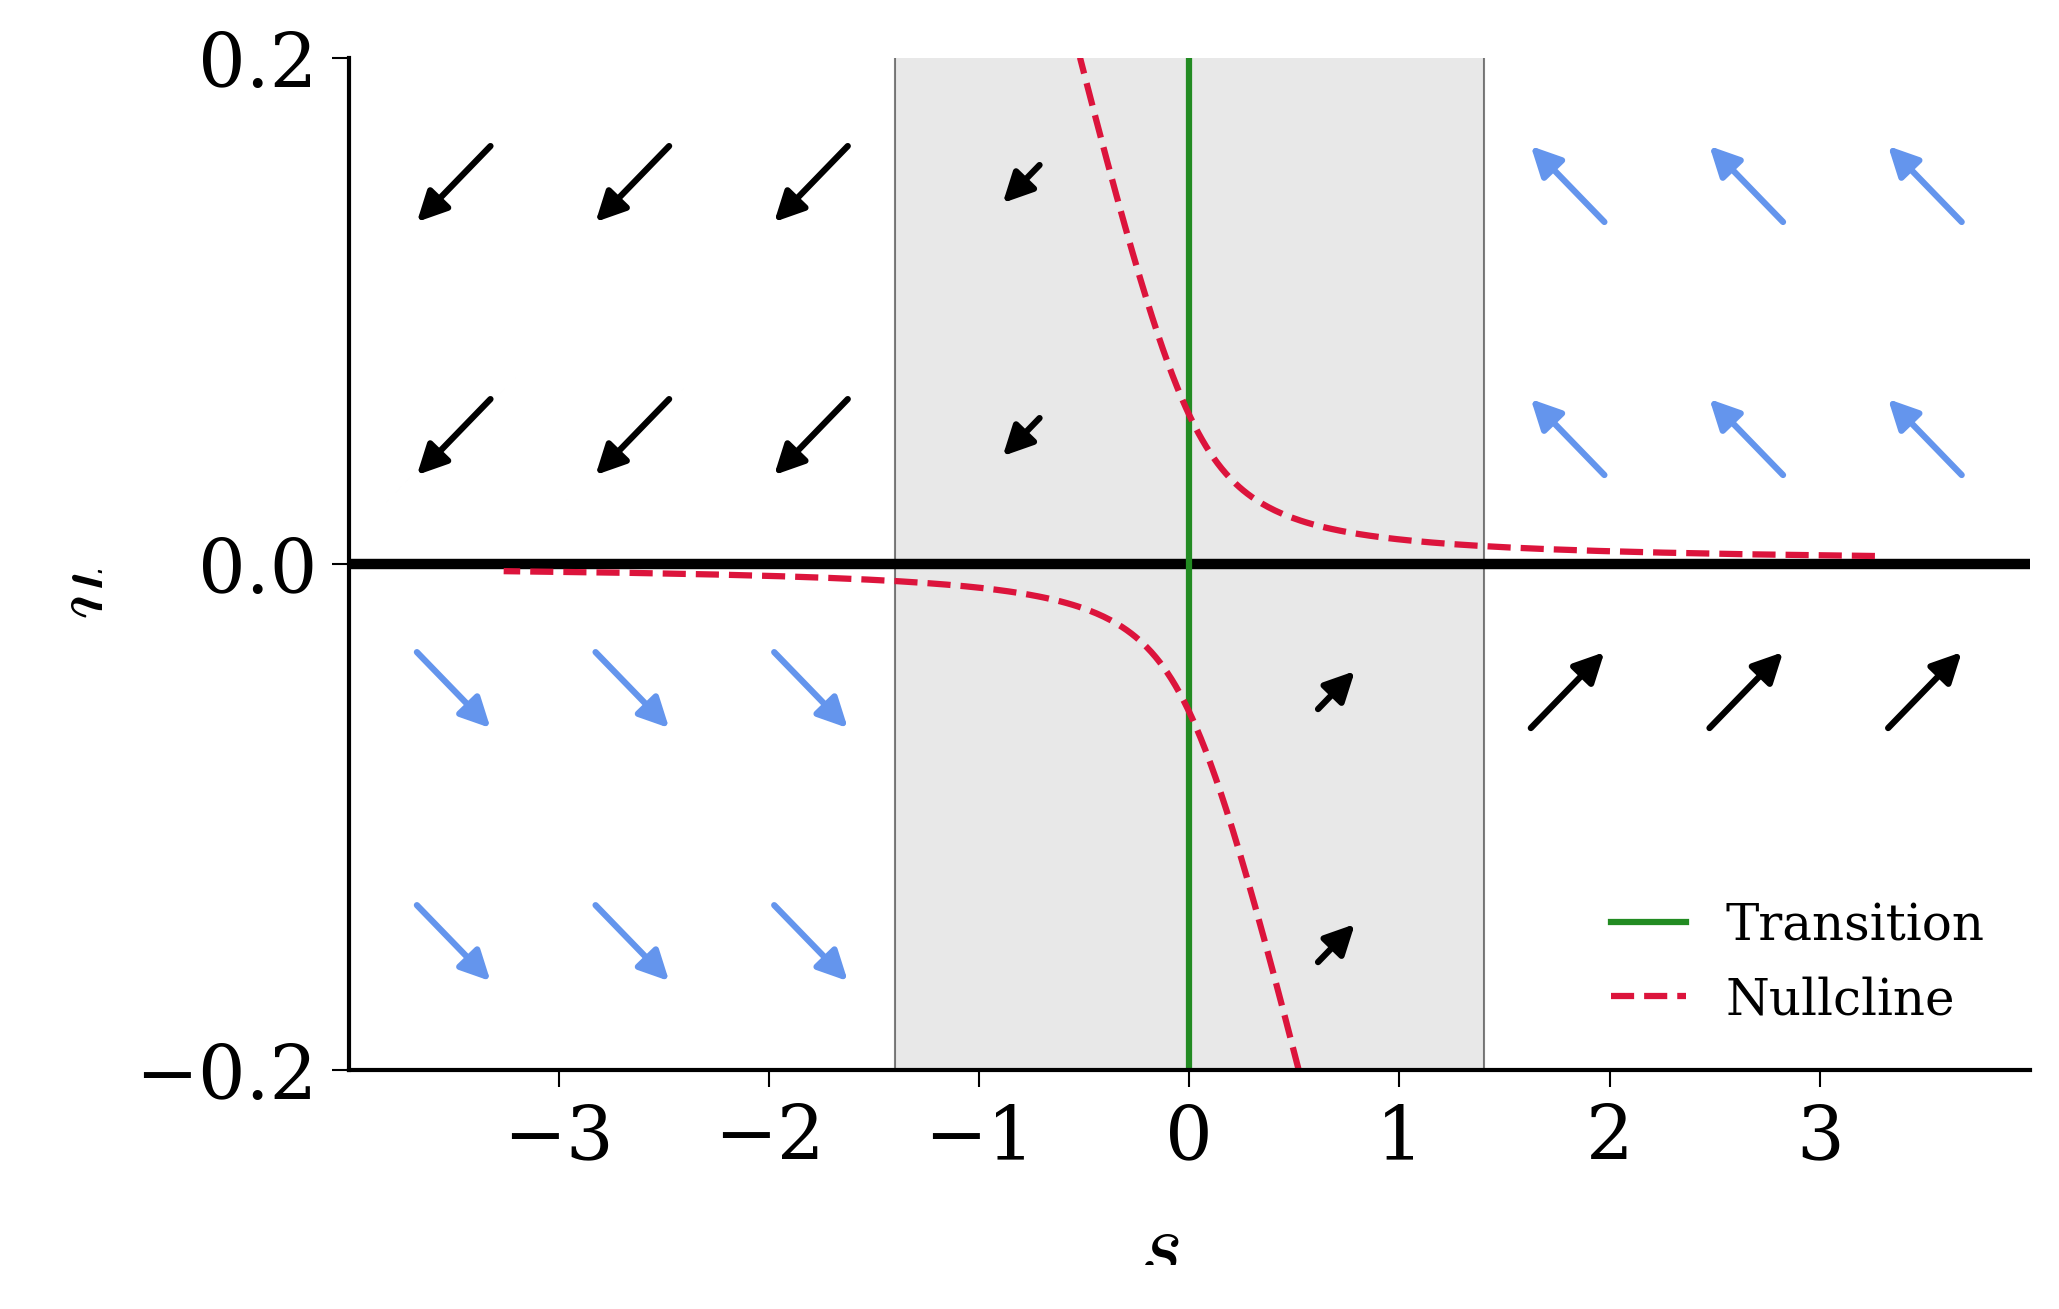

In [15]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')
from matplotlib import patches as mpatches


def f(u, s):
    du = u*(alpha + beta*s*u + gamma*u**2)
    ds = u*(zeta + eta*s**2 )
    return du, ds

def nullcline(u):
    return -alpha/(beta*u) - (gamma/(beta))*u

def plot_quiver(u_min:float, u_max:float, s_min:float, s_max:float, ):
    u_min, u_max = -0.3, 0.3
    s_min, s_max = -4., 4.
    #s_min, s_max = -9, 9

    u_q = np.linspace(u_min+0.05, u_max-0.05, 12)
    s_q = np.linspace(s_min+0.05, s_max-0.05, 12)
    Uq, Sq = np.meshgrid(u_q, s_q)   
    DUq, DSq = f(Uq, Sq)
    norm = np.sqrt(DUq**2 + DSq**2)
    norm[norm == 0] = 1
    return u_q, s_q, Uq, Sq, DUq, DSq, norm

def draw_arrow(ax, xy_start, xy_end, color):
    ax.annotate(
        '', xy=xy_end, xytext=xy_start,
        arrowprops=dict(
            arrowstyle='-|>',     
            color=color,
            lw=1.5,
            mutation_scale=15,    
            shrinkA=0, shrinkB=0
        )
    )

def is_outside_nullcline(s, u):
    if u == 0:
        return False
    s_null = nullcline(u)
    return abs(s) > abs(s_null)

def draw_flow_grid(ax, s_min, s_max, u_min, u_max,
                    n_s=7, n_u=4,
                    dx=0.35, dy=0.03, length_ratio_gray=0.5):
    s_grid = np.linspace(s_min + 0.3, s_max - 0.3, n_s)
    u_grid = np.linspace(u_min + 0.05, u_max - 0.05, n_u)

    for u0 in u_grid:
        for s0 in s_grid:
            outside = u0>0 and s0 > nullcline(u0) or u0<0 and s0 < nullcline(u0)
            if s0 >0:
                if outside:
                    color = 'cornflowerblue'
                    d = -dx
                    h = dy
                else:
                    color = 'black'
                    d = dx
                    h = dy

            elif s0<0:
                if outside:
                    color = 'cornflowerblue'
                    d = dx
                    h = -dy
                else:
                    color = 'black'
                    d = -dx
                    h = -dy

            if np.abs(s0) < 1.5:
                color = 'black'
                d = d * length_ratio_gray
                h = h * length_ratio_gray


            # direzione verticale in base al segno di s0
        

            draw_arrow(ax, (s0 - d/2, u0 - h/2), (s0 + d/2, u0 + h/2), color)


a, b, c, d = 2.0, 4.5, 1.0, 1.0
s_plus = (b*d**2+c*a**2)/(d*c*a)
u_plus = c*a**2/(c*a**2+b*d**2)

lambda4 = -b-a/s_plus -d*(1-2*u_plus) + c*s_plus**2*(2*u_plus - 3*u_plus**2)

dup_sp = -a*(1-u_plus)/s_plus**2 + 2*c*s_plus*(u_plus**2 - u_plus**3)
dup_um =(2*d + c*s_plus**2*(2 - 6*u_plus))/2

detA = (lambda4*u_plus - s_plus*dup_sp)

par = a/s_plus**2 + 2*c*s_plus*(2*u_plus -3*u_plus**2)

alpha = lambda4 
beta = -lambda4*par/(detA) + dup_sp*(c*s_plus**2*(2-6*u_plus) +2*d)/detA
gamma = -c*s_plus**2 + par*s_plus*dup_um/detA - u_plus*dup_um*(c*s_plus**2*(2-6*u_plus)+2*d)/(detA)

zeta = -d*(s_plus)
eta = (lambda4*a/(s_plus**2) - d*dup_sp)/detA

fig, ax = plt.subplots(1,1,figsize=(6.75, 4.25))

u_min, u_max = -0.2, 0.2
s_min, s_max = -4., 4.


#draw_flow_grid(ax, s_min, s_max, u_min, u_max)
draw_flow_grid(ax, s_min+0.2, -1.5,n_s=3, n_u=4,u_min=u_min, u_max=u_max)
draw_flow_grid(ax, -1.1, 0,n_s=1, n_u=2,u_min=0, u_max=u_max)
draw_flow_grid(ax, 0.4, 1.1,n_s=1, n_u=2,u_min=u_min, u_max=0)
draw_flow_grid(ax, 1.5, s_max-0.2,n_s=3, n_u=3,u_min=u_min+0.1, u_max=u_max)

ax.axhline(0, color='black', linewidth=2.5,)
ax.axvline(0, color='forestgreen', linewidth=1.5,ls ='-', label='Transition')


u_pos = np.linspace(0.001, u_max, 300)
u_neg = np.linspace(u_min, -0.001, 300)

for uu in (u_pos, u_neg):
    s_vals = nullcline(uu)
    mask = (s_vals > s_min) & (s_vals < s_max)
    ax.plot(s_vals[mask], uu[mask], color='crimson', linewidth=1.5, linestyle='--',
            label='Nullcline' if uu is u_pos else None)



rect = mpatches.Rectangle(
    (-1.4, s_min),                  
    2.8,                   
    s_max - s_min,                     
    linewidth=0.5,
    edgecolor='black',
    facecolor='lightgray',
    alpha=0.5,
    zorder=0,                          
)
ax.add_patch(rect)



ax.set_yticks([-0.2,0, 0.2])
ax.set_xticks([-3,-2,-1, 0, 1,2,3])

ax.set_xlim(s_min, s_max)
ax.set_ylim(u_min, u_max)
ax.set_xlabel(r'$s_-$', )
ax.set_ylabel(r'$u_-$',)
leg = ax.legend(loc='lower right',frameon=True,fontsize=12)
leg.get_frame().set_boxstyle('round,pad=0.4,rounding_size=0.2') 
leg.get_frame().set_edgecolor('none') 
leg.get_frame().set_alpha(1)

plt.savefig('flow_field.png',)
plt.show()

<>:736: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:736: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
/var/folders/tx/tcb2jb8j5wv__2wyr30by0gc0000gn/T/ipykernel_3813/789576193.py:736: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  ax[1].set_xlabel("$\Omega$")


Parameters: a=2.0, b=4.25, c=1.0, d=1.0: check b vallue before running
Analytical coefficients (Method-B slow-manifold reduction):
  Sp*        = 4.12500
  Up*        = 0.48485
  lambda_um  = -0.265152
  alpha      = -0.2652 (paper's alpha)
  beta      = 3.0078 (paper's beta)
  gamma      = 9.9474   (paper's gamma)
  zeta      = -4.1250 (paper's zeta)
  eta      = 0.2424 (paper's eta)

Tested for volumes: [  500.          1363.63636364  2227.27272727  3090.90909091
  3954.54545455  4818.18181818  5681.81818182  6545.45454545
  7409.09090909  8272.72727273  9136.36363636 10000.        ]
Failures: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Failures: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Failures: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Failures: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Failures: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Failures: [0.0, 0.0, 0.0, 0.0, 0.0]
Failures: [0.0, 0.0, 0.0, 0.0, 0.0]
Failures: [0.0, 0.0, 0.0, 0.0, 0.0]
Failures: [0.0, 0.0, 0.0, 0.0, 0.0]
Failures: [0.

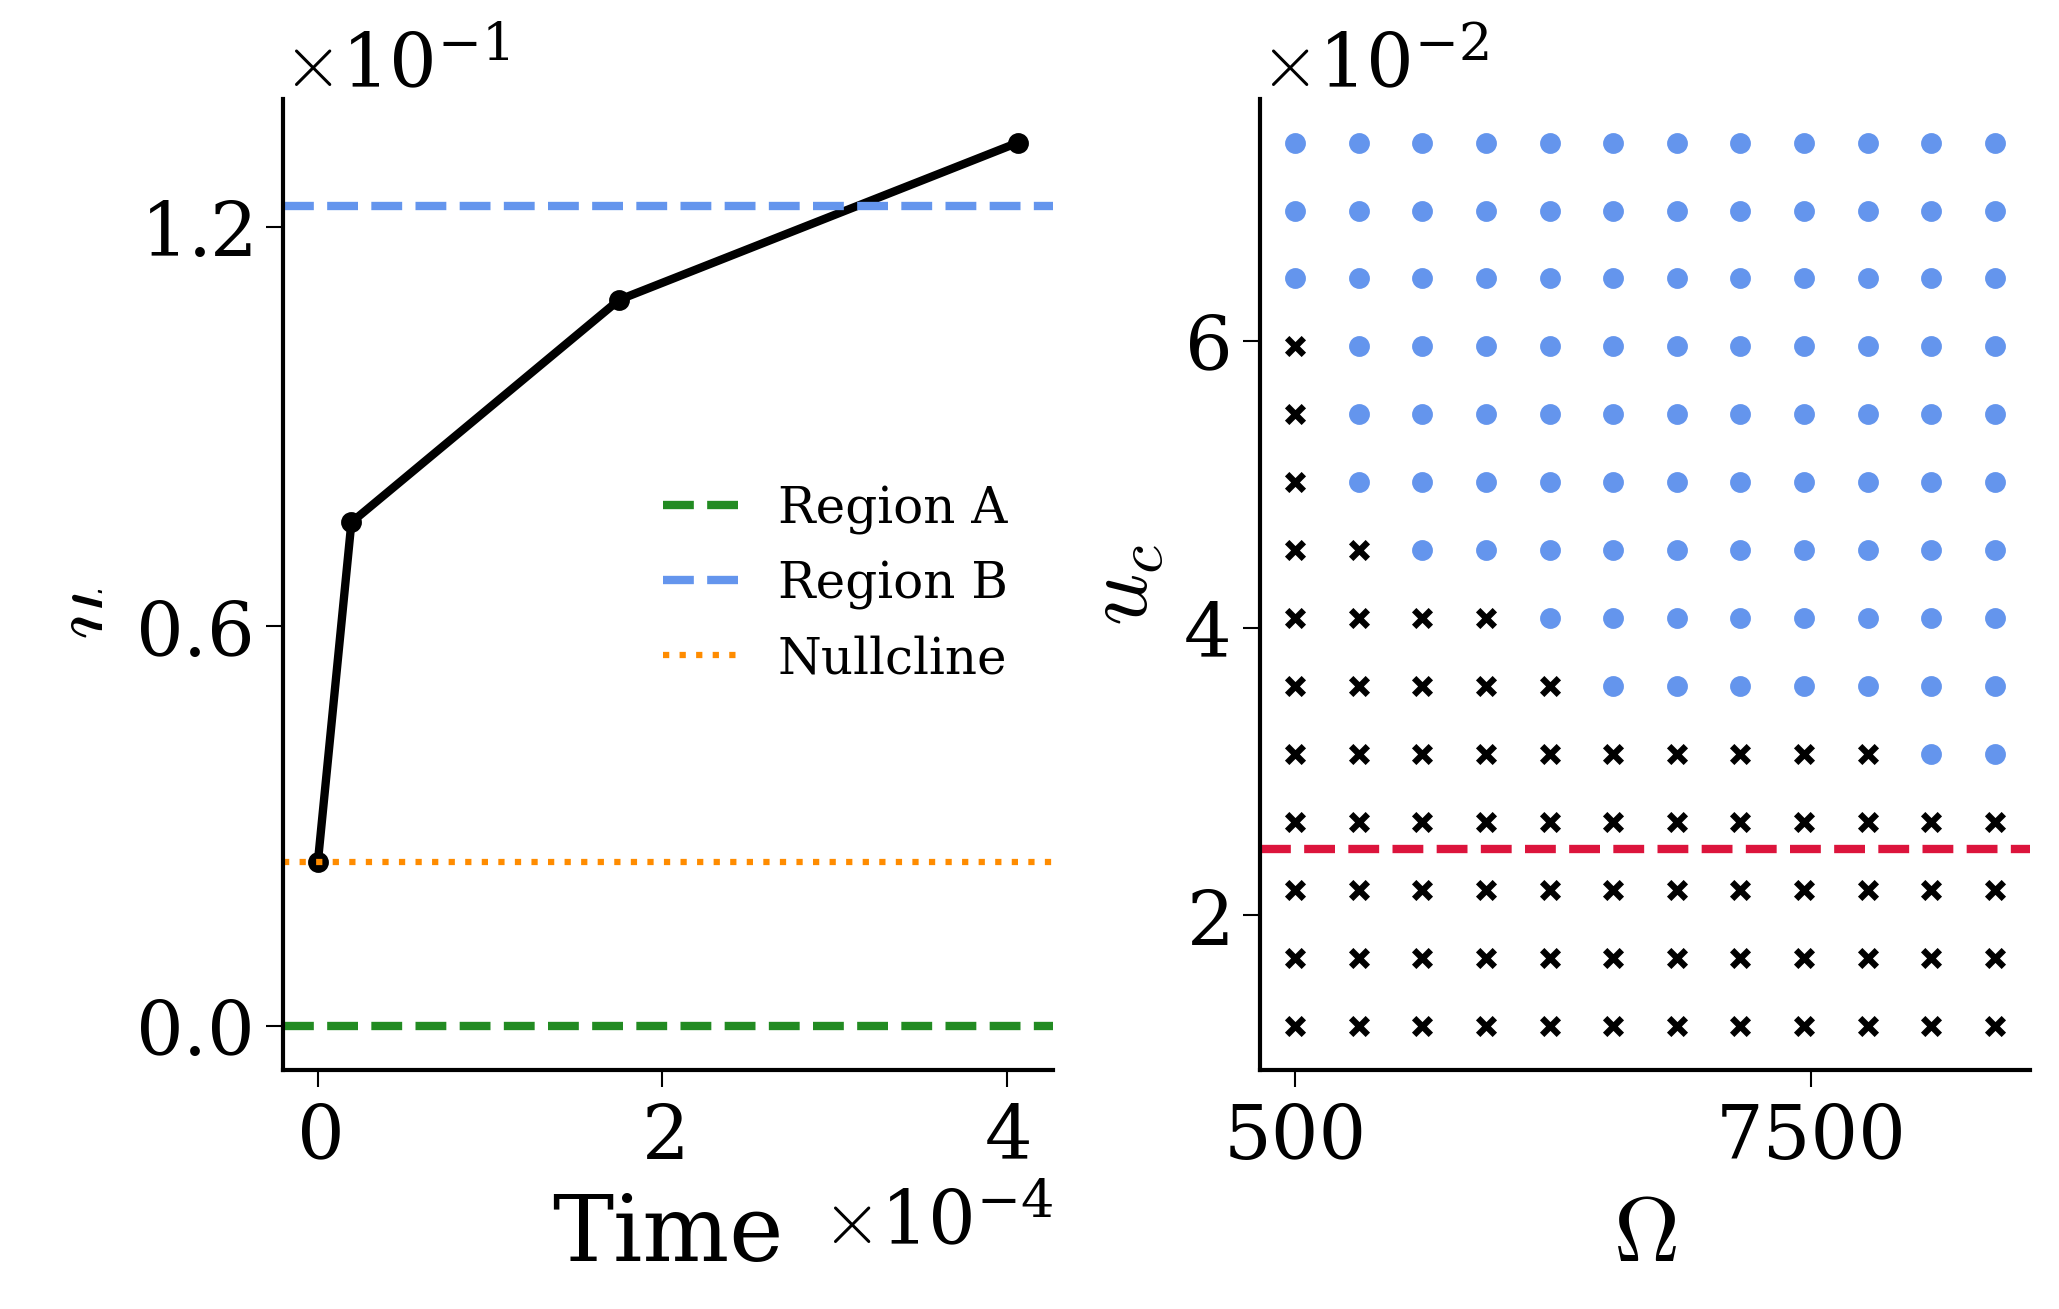

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from concurrent.futures import ProcessPoolExecutor, as_completed
plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')

try:
    from numba import njit, prange
    HAVE_NUMBA = True
except ImportError:
    HAVE_NUMBA = False

def parameters(a: float, b: float, c: float, d: float) -> dict:

    s_plus = (b*d**2+c*a**2)/(d*c*a)
    u_plus = c*a**2/(c*a**2+b*d**2)

    #coefficients computed as described in appendix C after substitution

    lambda4 = -b-a/s_plus -d*(1-2*u_plus) + c*s_plus**2*(2*u_plus - 3*u_plus**2)

    dup_sp = -a*(1-u_plus)/s_plus**2 + 2*c*s_plus*(u_plus**2 - u_plus**3)
    dup_um =(2*d + c*s_plus**2*(2 - 6*u_plus))/2

    detA = (lambda4*u_plus - s_plus*dup_sp)

    par = a/s_plus**2 + 2*c*s_plus*(2*u_plus -3*u_plus**2)

    alpha = lambda4 
    beta = -lambda4*par/(detA) + dup_sp*(c*s_plus**2*(2-6*u_plus) +2*d)/detA
    gamma = -c*s_plus**2 + par*s_plus*dup_um/detA - u_plus*dup_um*(c*s_plus**2*(2-6*u_plus)+2*d)/(detA)

    zeta = -d*(s_plus)
    eta = (lambda4*a/(s_plus**2) - d*dup_sp)/detA


    return dict(s_plus=s_plus, u_plus=u_plus, lambda_u=lambda4, alpha=alpha, beta=beta, gamma=gamma, zeta=zeta, eta=eta)

def initial_conditions(u0: float, s0: float, u_plus: float, s_plus: float) -> dict:

    x0 = (u0+u_plus)*(s0+s_plus)/2
    x1 = (u_plus-u0)*(s_plus-s0)/2
    y0 = (s0+s_plus)/2 - x0
    y1 = (s_plus-s0)/2 - x1

    return np.array([x0, y0, x1, y1])



def rk4_step_det(state: np.ndarray, h: float,
             a: float, b: float, c: float, d: float, v0: float, omega: float) -> np.ndarray:
    k1 = f_det(state, a, b, c, d, v0, omega)
    k2 = f_det(state + 0.5 * h * k1, a, b, c, d, v0, omega)
    k3 = f_det(state + 0.5 * h * k2, a, b, c, d, v0, omega)
    k4 = f_det(state + h * k3, a, b, c, d, v0, omega)
    return state + h * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0

def f_det(state: np.ndarray, a: float, b: float, c: float, d: float, v0: float, omega: float) -> np.ndarray:
    x0, y0, x1, y1  = state

    #v1 = omega - v0
    v1 = omega - v0
    dx0 = a*v0 -(b+d)*x0 + c*x0**2*y0/(v0**2)
    dy0 = b*x0 - c*x0**2*y0/(v0**2)
    dx1 = a*v1 -(b+d)*x1 + c*x1**2*y1/(v1**2)
    dy1 = b*x1 - c*x1**2*y1/(v1**2)

    return np.array([dx0, dy0, dx1, dy1])

def f_noise(state: np.ndarray, a: float, b: float, c: float, d: float, v0: float, omega: float, rng: np.random.Generator) -> np.ndarray:
    x0, y0, x1, y1 = state
    v1 = omega - v0
    A1, A2, A3, A4 = a*v0, d*x0, b*x0, c*x0**2*y0/v0**2
    B1, B2, B3, B4 = a*v1, d*x1, b*x1, c*x1**2*y1/v1**2

    max_std = np.array([np.sqrt(A1)+np.sqrt(A2) + np.sqrt(A3) + np.sqrt(A4), np.sqrt(A3)+np.sqrt(A4), np.sqrt(B1)+np.sqrt(B2) + np.sqrt(B3) + np.sqrt(B4), np.sqrt(B3)+np.sqrt(B4)])

    dW = rng.normal(size=8) 
    dx0 = np.sqrt(A1)*dW[0] - np.sqrt(A2)*dW[1] - np.sqrt(A3)*dW[2] + np.sqrt(A4)*dW[3]
    dy0 = np.sqrt(A3)*dW[2] - np.sqrt(A4)*dW[3]
    dx1 = np.sqrt(B1)*dW[4] - np.sqrt(B2)*dW[5] - np.sqrt(B3)*dW[6] + np.sqrt(B4)*dW[7]
    dy1 = np.sqrt(B3)*dW[6] - np.sqrt(B4)*dW[7]
    return np.array([dx0, dy0, dx1, dy1]), max_std



def Euler_Maruyama(state: np.ndarray, t0: float, T: float, dt: float,a: float, b: float, c: float, d: float,seed=None,Vol:float=5000):
    'Integrate the LNA using the Euler-Maruyama method. '
    'This function checks if the transition (swap of volumes) occurs and stops the integration if it does.'
    'Returns the time array, trajectory, standard deviation of u, exit flag, and the step at which exit occurred.'
    
    rng = np.random.default_rng(seed)
    n_steps = int((T - t0) / dt)
    n = len(state)
    exit = False
    n_break = n_steps
    x0, y0, x1, y1 = state

    t = np.linspace(t0, T, n_steps + 1)
    traj = np.full((n_steps + 1, n), np.nan)
    traj[0] = state.copy()
    arr_std_u = np.full((n_steps, 1), np.nan)
    for i in range(n_steps):
        v0 = (state[0] + state[1])*Vol/(state[0] + state[1] + state[2] + state[3])
        if (v0-(Vol -v0)) < 0:
            exit = True
            n_break = i+1
            break

        delta, max_std =  f_noise(state, a, b, c, d, v0, Vol, rng) 
        step_det = rk4_step_det(state, dt, a, b, c, d, v0, Vol)  
        delta_u_1, delta_u_2 = err_u(state, delta)
        arr_std_u[i] = delta_u_1 * np.sqrt(dt) + delta_u_2 * dt
        state = step_det  + delta * np.sqrt(dt)
        if np.any(state < 0):
            print(f"Warning: State has become negative at step {i}. Stopping integration.")
            print(f"State: {state}")
            break
        traj[i + 1] = state
        
    
    return t, traj, arr_std_u, exit, n_break,

def nullcline(s_arr: np.ndarray, lambda_u:float, beta:float, gamma:float) -> np.ndarray:
    """
    Analytical escape threshold |Delta u_-| as a function of s_-.
    Uses the rationalised form to remain numerically stable at s_- = 0.
    return both brances of the solution
    """

    disc = np.sqrt(beta * beta * s_arr * s_arr - 4.0 * gamma * lambda_u)
    return [(-beta *s_arr + disc) / (2.0 * gamma), (-beta * s_arr - disc) / (2.0 * gamma)]

def reduced_variables(traj: np.ndarray) -> np.ndarray:
    """
    Compute the reduced variables from the trajectory in ohysical variables.
    """
    s0 = traj[:,0] + traj[:,1]
    s1 = traj[:,2] + traj[:,3]
    u0 = (traj[:,0] / s0) /2
    u1 = (traj[:,2] / s1) /2
    sm = s0 - s1
    sp = s0 + s1
    um = u0 - u1
    up = u0 + u1
    return np.array([sp,up,sm,um])

def err_u(state: np.ndarray, delta: np.ndarray) -> float:
    x0, y0, x1, y1 = state
    dx0, dy0, dx1, dy1 = delta
    delta_u_1 = 0.5*(y0*dx0/(x0+y0)**2 - x0*dy0/(x0+y0)**2 - y1*dx1/(x1+y1)**2 + x1*dy1/(x1+y1)**2)
    delta_u_2 = 0.5*0.5*(-2*y0*(dx0)**2/(x0+y0)**3 + 2*(x0-y0)*dx0*dy0/(x0+y0)**3 + 2*x0*(dy0)**2/(x0+y0)**3 + 2*y1*(dx1)**2/(x1+y1)**3 - 2*(x1-y1)*dx1*dy1/(x1+y1)**3 - 2*x1*(dy1)**2/(x1+y1)**3)
    return delta_u_1, delta_u_2

def commutor_target(state, t0, T, dt, a, b, c, d, seed=None, Vol=5000, coeffs=None, s0=3.5,u_a_threshold=None, u_b_threshold=None):
    """
    Integrate the LNA using the Euler-Maruyama method until the reduced variable u crosses either threshold u_a or u_b.
    Returns the time array, trajectory and a success flag indicating which threshold was crossed.
    """

    rng = np.random.default_rng(seed)
    n_steps = int((T - t0) / dt)
    n = len(state)
    n_break = n_steps
    success = -1
    middle_region = 0

    t = np.linspace(t0, T, n_steps + 1)
    traj = np.full((n_steps + 1, n), np.nan)
    traj[0] = state.copy()
    #arr_std_u = np.full((n_steps, 1), np.nan)

    for i in range(n_steps):
        v0 = (state[0] + state[1]) * Vol / (state[0] + state[1] + state[2] + state[3])

        delta, max_std = f_noise(state, a, b, c, d, v0, Vol, rng)
        step_det = rk4_step_det(state, dt, a, b, c, d, v0, Vol)
        #arr_std_u[i] = err_u(state, max_std) * np.sqrt(dt)
        state = step_det + delta * np.sqrt(dt)

        if np.any(state < 0):
            print(f"Warning: State has become negative at step {i}. Stopping integration.")
            print(f"State: {state}")
            break

        traj[i + 1] = state

        # only check the current point, not the whole history
        u_now = reduced_variables((state / Vol)[None, :])[3, 0]
        if u_now > u_b_threshold:
            success = 1
            break
        if u_now < u_a_threshold:
            success = 0
            break
    

    return t, traj, success

def commutor_target_Gillespie(state, t0, T, dt, a, b, c, d, Vol=5000, s0=3.5,u_a_threshold=None, u_b_threshold=None):
    """
    Integrate the LNA using the Euler-Maruyama method until the reduced variable u crosses either threshold u_a or u_b.
    Returns the time array, trajectory and a success flag indicating which threshold was crossed.
    """

    max_n_steps = int((T - t0) / dt)
    n = len(state)
    n_break = max_n_steps
    success = -1
    middle_region = 0

    t = [0 ]
    traj = np.full((max_n_steps + 1, n), np.nan)
    traj[0] = state.copy()

    i=0
    while i < max_n_steps and t[i] < T:
        v0 = (state[0] + state[1]) * Vol / (state[0] + state[1] + state[2] + state[3])

        t_step, traj_step = Gillespie_algorithm(state, 1, a, b, c, d, Vol,T)
        state = traj_step[-1]
        t.append(t[i] + t_step[-1]) 

        traj[i + 1] = state

        # only check the current point, not the whole history
        u_now = (0.5*state[0]/(state[0] + state[1])  - 0.5*state[2]/(state[2] + state[3]))
        if u_now > u_b_threshold:
            success = 1
            break
        if u_now < u_a_threshold:
            success = 0
            break
        i += 1

    return t, traj, success

def Gillespie_algorithm(ic, n_steps, a, b, c, d, Vol,T_max):
   

    x0, y0, x1, y1 = ic[0], ic[1], ic[2], ic[3]

    t_list = [0]
    traj_x0 = [x0]
    traj_y0 = [y0]
    traj_x1 = [x1]
    traj_y1 = [y1]

    t_cur = 0

    for _ in range(n_steps):
        s_tot = x0 + y0 + x1 + y1
        v0 = (x0 + y0) * Vol / s_tot
        v1 = Vol - v0

        # Propensities
        a1 = a * v0
        a2 = b * x0
        a3 = d * x0
        a4 = c * x0 * x0 * y0 / (v0 * v0)
        a5 = a * v1
        a6 = b * x1
        a7 = d * x1
        a8 = c * x1 * x1 * y1 / (v1 * v1)

        total_propensity = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8

        if total_propensity == 0.0:
            break

        # Time to next reaction
        tau = -np.log(np.random.random()) / total_propensity
        t_cur += tau

        # Determine which reaction occurs
        r = np.random.random() * total_propensity
        cum = a1
        if r < cum:
            reaction_index = 0
        else:
            cum += a2
            if r < cum:
                reaction_index = 1
            else:
                cum += a3
                if r < cum:
                    reaction_index = 2
                else:
                    cum += a4
                    if r < cum:
                        reaction_index = 3
                    else:
                        cum += a5
                        if r < cum:
                            reaction_index = 4
                        else:
                            cum += a6
                            if r < cum:
                                reaction_index = 5
                            else:
                                cum += a7
                                if r < cum:
                                    reaction_index = 6
                                else:
                                    reaction_index = 7

        if reaction_index == 0:
            x0 += 1
        elif reaction_index == 1:
            x0 -= 1
            y0 += 1
        elif reaction_index == 2:
            x0 -= 1
        elif reaction_index == 3:
            x0 += 1
            y0 -= 1
        elif reaction_index == 4:
            x1 += 1
        elif reaction_index == 5:
            x1 -= 1
            y1 += 1
        elif reaction_index == 6:
            x1 -= 1
        elif reaction_index == 7:
            x1 += 1
            y1 -= 1


        t_list.append(t_cur)
        traj_x0.append(x0)
        traj_y0.append(y0)
        traj_x1.append(x1)
        traj_y1.append(y1)
        if t_cur > T_max:
            break

    t = np.array(t_list)
    traj = np.column_stack((
    np.asarray(traj_x0),
    np.asarray(traj_y0),
    np.asarray(traj_x1),
    np.asarray(traj_y1),
    ))

    return t, traj

def target_q(q: list, threshold = 0.5):
    
    index_target = 0
    success = False
    for index, q_val in enumerate(q):
        if q_val > 0.5:
            success = True
            index_target = index
            break
    if success == False: 
        index_target = -1
        print('Threshold not detected in the list of q values. Returning the last index.')
    return index_target, success




def _worker_single_trajectory(seed, ic, t0, T, dt, a, b, c, d, Vol,
                               u_a_threshold, u_b_threshold):
    
    _, _, success = commutor_target(
        ic, t0, T, dt, a, b, c, d,
        seed=seed, Vol=Vol,
        u_a_threshold=u_a_threshold, u_b_threshold=u_b_threshold,
    )
    return success

def _worker_single_trajectory_gillespie(seed, ic, t0, T, dt, a, b, c, d, Vol,
                                          u_a_threshold, u_b_threshold):
    np.random.seed(seed) 
    _, _, success = commutor_target_Gillespie(
        ic, t0, T, dt, a, b, c, d,
        Vol=Vol, u_a_threshold=u_a_threshold, u_b_threshold=u_b_threshold,
    )
    return success


def run_batch_parallel(ic, seeds, t0, T, dt, a, b, c, d, Vol,
                        u_a_threshold, u_b_threshold, n_workers=None,
                        executor=None):

    n_seeds = len(seeds)
    results = np.empty(n_seeds, dtype=int)

    def _submit(ex):
        '''futures = {
            ex.submit(_worker_single_trajectory, seed, ic, t0, T, dt,
                      a, b, c, d, Vol, u_a_threshold, u_b_threshold): i
            for i, seed in enumerate(seeds)
        }'''
        futures = {
            ex.submit(_worker_single_trajectory_gillespie, seed, ic, t0, T, dt,
                      a, b, c, d, Vol, u_a_threshold, u_b_threshold): i
            for i, seed in enumerate(seeds)
        }
        for fut in as_completed(futures):
            i = futures[fut]
            results[i] = fut.result()

    if executor is not None:
        _submit(executor)
    else:
        n_workers = n_workers or os.cpu_count()
        with ProcessPoolExecutor(max_workers=n_workers) as ex:
            _submit(ex)

    return results


def gillespie_to_threshold(x0, y0, x1, y1, a, b, c, d, Vol, T_max,
                            u_a_threshold, u_b_threshold, seed=None):
    """
    Esegue una singola traiettoria SSA fino a T_max o fino a quando la
    variabile ridotta u supera una delle due soglie.
 
    Ritorna: 1 se u supera u_b_threshold, 0 se scende sotto
    u_a_threshold, -1 se arriva a T_max senza decidere.
    """
    rng = random.Random(seed)
    t_cur = 0.0
 
    while t_cur < T_max:
        s_tot = x0 + y0 + x1 + y1
        v0 = (x0 + y0) * Vol / s_tot
        v1 = Vol - v0
 
        a1 = a * v0
        a2 = b * x0
        a3 = d * x0
        a4 = c * x0 * x0 * y0 / (v0 * v0)
        a5 = a * v1
        a6 = b * x1
        a7 = d * x1
        a8 = c * x1 * x1 * y1 / (v1 * v1)
 
        a_tot = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8
        if a_tot <= 0.0:
            break
 
        tau = -math.log(rng.random()) / a_tot
        t_cur += tau
 
        r = rng.random() * a_tot
        c1 = a1
        c2 = c1 + a2
        c3 = c2 + a3
        c4 = c3 + a4
        c5 = c4 + a5
        c6 = c5 + a6
        c7 = c6 + a7
 
        if r < c1:
            x0 += 1
        elif r < c2:
            x0 -= 1; y0 += 1
        elif r < c3:
            x0 -= 1
        elif r < c4:
            x0 += 1; y0 -= 1
        elif r < c5:
            x1 += 1
        elif r < c6:
            x1 -= 1; y1 += 1
        elif r < c7:
            x1 -= 1
        else:
            x1 += 1; y1 -= 1
 
        u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
        if u_now > u_b_threshold:
            return 1
        if u_now < u_a_threshold:
            return 0
 
    return -1
 
 
def run_batch_python(ic, seeds, a, b, c, d, Vol, T_max,
                      u_a_threshold, u_b_threshold):
    """Fallback puro Python: loop sui seed (usa comunque multiprocessing
    esternamente se vuoi sfruttare piu' core, ma ora ogni task e'
    molto piu' leggero perche' non alloca array)."""
    x0_ic, y0_ic, x1_ic, y1_ic = ic
    results = np.empty(len(seeds), dtype=np.int64)
    for i, seed in enumerate(seeds):
        results[i] = gillespie_to_threshold(
            x0_ic, y0_ic, x1_ic, y1_ic, a, b, c, d, Vol, T_max,
            u_a_threshold, u_b_threshold, seed=int(seed),
        )
    return results
 
 
if HAVE_NUMBA:
 
    @njit(cache=True, fastmath=True)
    def _gillespie_to_threshold_nb(x0, y0, x1, y1, a, b, c, d, Vol, T_max,
                                    u_a_threshold, u_b_threshold):
        t_cur = 0.0
        while t_cur < T_max:
            s_tot = x0 + y0 + x1 + y1
            v0 = (x0 + y0) * Vol / s_tot
            v1 = Vol - v0
 
            a1 = a * v0
            a2 = b * x0
            a3 = d * x0
            a4 = c * x0 * x0 * y0 / (v0 * v0)
            a5 = a * v1
            a6 = b * x1
            a7 = d * x1
            a8 = c * x1 * x1 * y1 / (v1 * v1)
 
            a_tot = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8
            if a_tot <= 0.0:
                break
 
            tau = -np.log(np.random.random()) / a_tot
            t_cur += tau
 
            r = np.random.random() * a_tot
            c1 = a1
            c2 = c1 + a2
            c3 = c2 + a3
            c4 = c3 + a4
            c5 = c4 + a5
            c6 = c5 + a6
            c7 = c6 + a7
 
            if r < c1:
                x0 += 1
            elif r < c2:
                x0 -= 1; y0 += 1
            elif r < c3:
                x0 -= 1
            elif r < c4:
                x0 += 1; y0 -= 1
            elif r < c5:
                x1 += 1
            elif r < c6:
                x1 -= 1; y1 += 1
            elif r < c7:
                x1 -= 1
            else:
                x1 += 1; y1 -= 1
 
            u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
            if u_now > u_b_threshold:
                return 1
            if u_now < u_a_threshold:
                return 0
 
        return -1
 
    @njit(parallel=True, cache=True, fastmath=True)
    def run_batch_numba(x0_ic, y0_ic, x1_ic, y1_ic, seeds,
                         a, b, c, d, Vol, T_max,
                         u_a_threshold, u_b_threshold):
        n = seeds.shape[0]
        results = np.empty(n, dtype=np.int64)
        for i in prange(n):
            np.random.seed(seeds[i])
            results[i] = _gillespie_to_threshold_nb(
                x0_ic, y0_ic, x1_ic, y1_ic, a, b, c, d, Vol, T_max,
                u_a_threshold, u_b_threshold,
            )
        return results
 
 
# ----------------------------------------------------------------------
# Wrapper unico da usare al posto di run_batch_parallel(...) nel loop
# principale di main().
# ----------------------------------------------------------------------
def run_batch_fast(ic, seeds, a, b, c, d, Vol, T_max,
                    u_a_threshold, u_b_threshold):
    seeds = np.asarray(seeds, dtype=np.int64)
    if HAVE_NUMBA:
        x0, y0, x1, y1 = (float(v) for v in ic)
        return run_batch_numba(x0, y0, x1, y1, seeds, a, b, c, d, Vol,
                                T_max, u_a_threshold, u_b_threshold)
    else:
        return run_batch_python(ic, seeds, a, b, c, d, Vol, T_max,
                                 u_a_threshold, u_b_threshold)
 
 


def main() -> None:
    a, b, c, d = 2.0, 4.25, 1.0, 1.0
    #a, b, c, d = 2.0, 4.15, 1.0, 1.0
    print(f"Parameters: a={a}, b={b}, c={c}, d={d}: check b vallue before running")
    coeffs = parameters(a, b, c, d)
    Sp_star = coeffs["s_plus"]

    print("Analytical coefficients (Method-B slow-manifold reduction):")
    print(f"  Sp*        = {coeffs['s_plus']:.5f}")
    print(f"  Up*        = {coeffs['u_plus']:.5f}")
    print(f"  lambda_um  = {coeffs['lambda_u']:.6f}")
    print(f"  alpha      = {coeffs['alpha']:.4f} (paper's alpha)")
    print(f"  beta      = {coeffs['beta']:.4f} (paper's beta)")
    print(f"  gamma      = {coeffs['gamma']:.4f}   (paper's gamma)")
    print(f"  zeta      = {coeffs['zeta']:.4f} (paper's zeta)")
    print(f"  eta      = {coeffs['eta']:.4f} (paper's eta)")
    print()

    T=100.0
    dt=0.001
    n_steps = int((T - 0) / dt)
    s0 =3.5
    u0 = 0
    arr_n_passed = []
    Vol = 5000
    #Volumes = [5000.0]
    N_traj = 1000

    n_workers = os.cpu_count()

    #==================================
    #one trajectory to visualise the dynamics
    #==================================
    ic = initial_conditions(u0, s0, coeffs['u_plus'], coeffs['s_plus']) * Vol
    
    q=[]
    failures = []
   

    u_a_threshold = 0
    u_b_threshold = 5 * nullcline(s0, coeffs['lambda_u'], coeffs['beta'], coeffs['gamma'])[0]
    #u0_arr = np.linspace(nullcline(s0, coeffs['lambda_u'], coeffs['beta'], coeffs['gamma'])[0], nullcline(s0, coeffs['lambda_u']/2, coeffs['beta'], coeffs['gamma'])[0]*6, 10)
    u0_arr = np.linspace(u_a_threshold, u_b_threshold, 20)

    if u_a_threshold < min(u0_arr) or u_b_threshold > max(u0_arr):
        print("Warning: Thresholds are outside the range of initial conditions.")
    

    #==================================
    #determine the dependence of the commutor function on the volume: use high value volume to prevent excessive noise system 
    #==================================

    arr_q_best = []
    arr_ic_best = []

    N_traj = 1000

    seeds_1000 = np.arange(N_traj)
    

    Volumes =  np.linspace(500, 10000, 12)
    #Volumes = [5000]
    print(f"Tested for volumes: {Volumes}")
    u0_arr_new = np.linspace(nullcline(s0, coeffs['lambda_u'], coeffs['beta'], coeffs['gamma'])[0]/2, nullcline(s0, coeffs['lambda_u'], coeffs['beta'], coeffs['gamma'])[0]*3, 14)


    for Vol in Volumes[:]:
        q=[]
        failures = []
        detection = False
        index=0
        ic_best = None
        for u0 in u0_arr_new:
            ic = initial_conditions(u0, s0, coeffs['u_plus'], coeffs['s_plus']) * Vol

            results = run_batch_fast(
            ic, seeds_1000, a, b, c, d, Vol, T,
            u_a_threshold, u_b_threshold,
            )
            region_b = int(np.sum(results == 1))
            mixed_region = int(np.sum(results == -1))

            q.append(region_b / N_traj)
            if q[-1] > 0.5:
                detection = True

                if index > 0:
                    ic_best = (u0_arr_new[index] + u0_arr_new[index-1]) / 2
                else:
                    ic_best = u0_arr_new[index]
                arr_q_best.append(q[-1])
                arr_ic_best.append(ic_best)
                break
            failures.append(mixed_region/N_traj)
            index += 1

        if detection == False:
            arr_q_best.append(0)
            arr_ic_best.append(0)
            ic_best = u0_arr_new[-1]
            print(f"Warning: No initial condition led to a frequency above 0.5 for volume {Vol}.")


        print(f"Failures: {failures}")

    success=0 
    np.random.seed(52)
    t=np.zeros(1)
    while success==0 and len(t)<20:
        t,traj,success=commutor_target_Gillespie(initial_conditions(nullcline(s0, coeffs['lambda_u'], coeffs['beta'], coeffs['gamma'])[0], s0, coeffs['u_plus'], coeffs['s_plus']), 0, T, dt, a, b, c, d, Vol=5000, s0=3.5,u_a_threshold=u_a_threshold, u_b_threshold=u_b_threshold)

    t = np.array(t)
    traj_valid = traj[:len(t)]
    traj_reduced = reduced_variables(traj_valid / 5000)
    fig, ax = plt.subplots(1,2,figsize=(6.75, 4.25))
    ax[0].plot(t, traj_reduced[3, :],marker='o', linestyle='-', color='black', lw=2)
    
    ax[0].axhline(u_a_threshold,color='forestgreen', ls='--',lw=2, label='Region A')
    ax[0].axhline(u_b_threshold,color='cornflowerblue', ls='--',lw=2, label='Region B')
    ax[0].axhline(nullcline(s0, coeffs['lambda_u'], coeffs['beta'], coeffs['gamma'])[0],color='darkorange', ls=':',lw=1.5, label='Nullcline')
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel(r"$u_-$")
    ax[0].set_yticks([0.0, 0.06, 0.12])
    ax[0].legend(fontsize=12)
    
    for i, Vol in enumerate(Volumes):
        threshold = arr_ic_best[i]
        for u0 in u0_arr_new:
            if u0 < threshold:
                ax[1].scatter(Vol, u0, color='black', marker='x')
            else:
                ax[1].scatter(Vol, u0, color='cornflowerblue', marker='o')
    ax[1].axhline(nullcline(s0, coeffs['lambda_u'], coeffs['beta'], coeffs['gamma'])[0],color='crimson', ls='--',lw=2, label='$u_-=0$')
    ax[0].ticklabel_format(style='sci',axis='x',scilimits=(0, 0),useMathText=True)
    #ax[1].set_xticklabels([r'$10^2$', r'$10^4$'],fontfamily='serif')
    ax[0].ticklabel_format(style='sci',axis='y',scilimits=(0, 0),useMathText=True)
    
        #ax[1].set_xticklabels([r'$10^2$', r'$10^4$'],fontfamily='serif')
    ax[1].ticklabel_format(style='sci',axis='y',scilimits=(0, 0),useMathText=True)
    ax[1].set_xticks([500, 7500])
    ax[1].set_yticks([0.02, 0.04, 0.06])
    ax[1].set_xlabel("$\Omega$")
    ax[1].set_ylabel("$u_c$")
    fig.savefig("noise_thresholds.png", )
    plt.show()

if __name__ == "__main__":
    main()

b = 4.35, D = 3.211952e-04 (k = 0.9459), (k/lambda = -5.5332)
b = 4.37, D = 2.757452e-04 (k = 0.7867), (k/lambda = -5.0674)
b = 4.38, D = 2.504434e-04 (k = 0.7042), (k/lambda = -5.0469)
b = 4.40, D = 2.341074e-04 (k = 0.6279), (k/lambda = -5.0713)
b = 4.42, D = 2.448979e-04 (k = 0.6591), (k/lambda = -6.0983)
b = 4.43, D = 2.190665e-04 (k = 0.5884), (k/lambda = -6.3711)
b = 4.45, D = 2.890203e-04 (k = 0.8172), (k/lambda = -10.6652)
b = 4.47, D = 2.062040e-04 (k = 0.5302), (k/lambda = -8.7076)
b = 4.48, D = 2.108455e-04 (k = 0.5136), (k/lambda = -11.3735)
b = 4.50, D = 2.503866e-04 (k = 0.6125), (k/lambda = -20.8252)


/Users/lhc642/Documents/Phd/Brusselator/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/Users/lhc642/Documents/Phd/Brusselator/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/lhc642/Documents/Phd/Brusselator/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/lhc642/Documents/Phd/Brusselator/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/lhc642/Documents/Phd/Brusselator/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/User

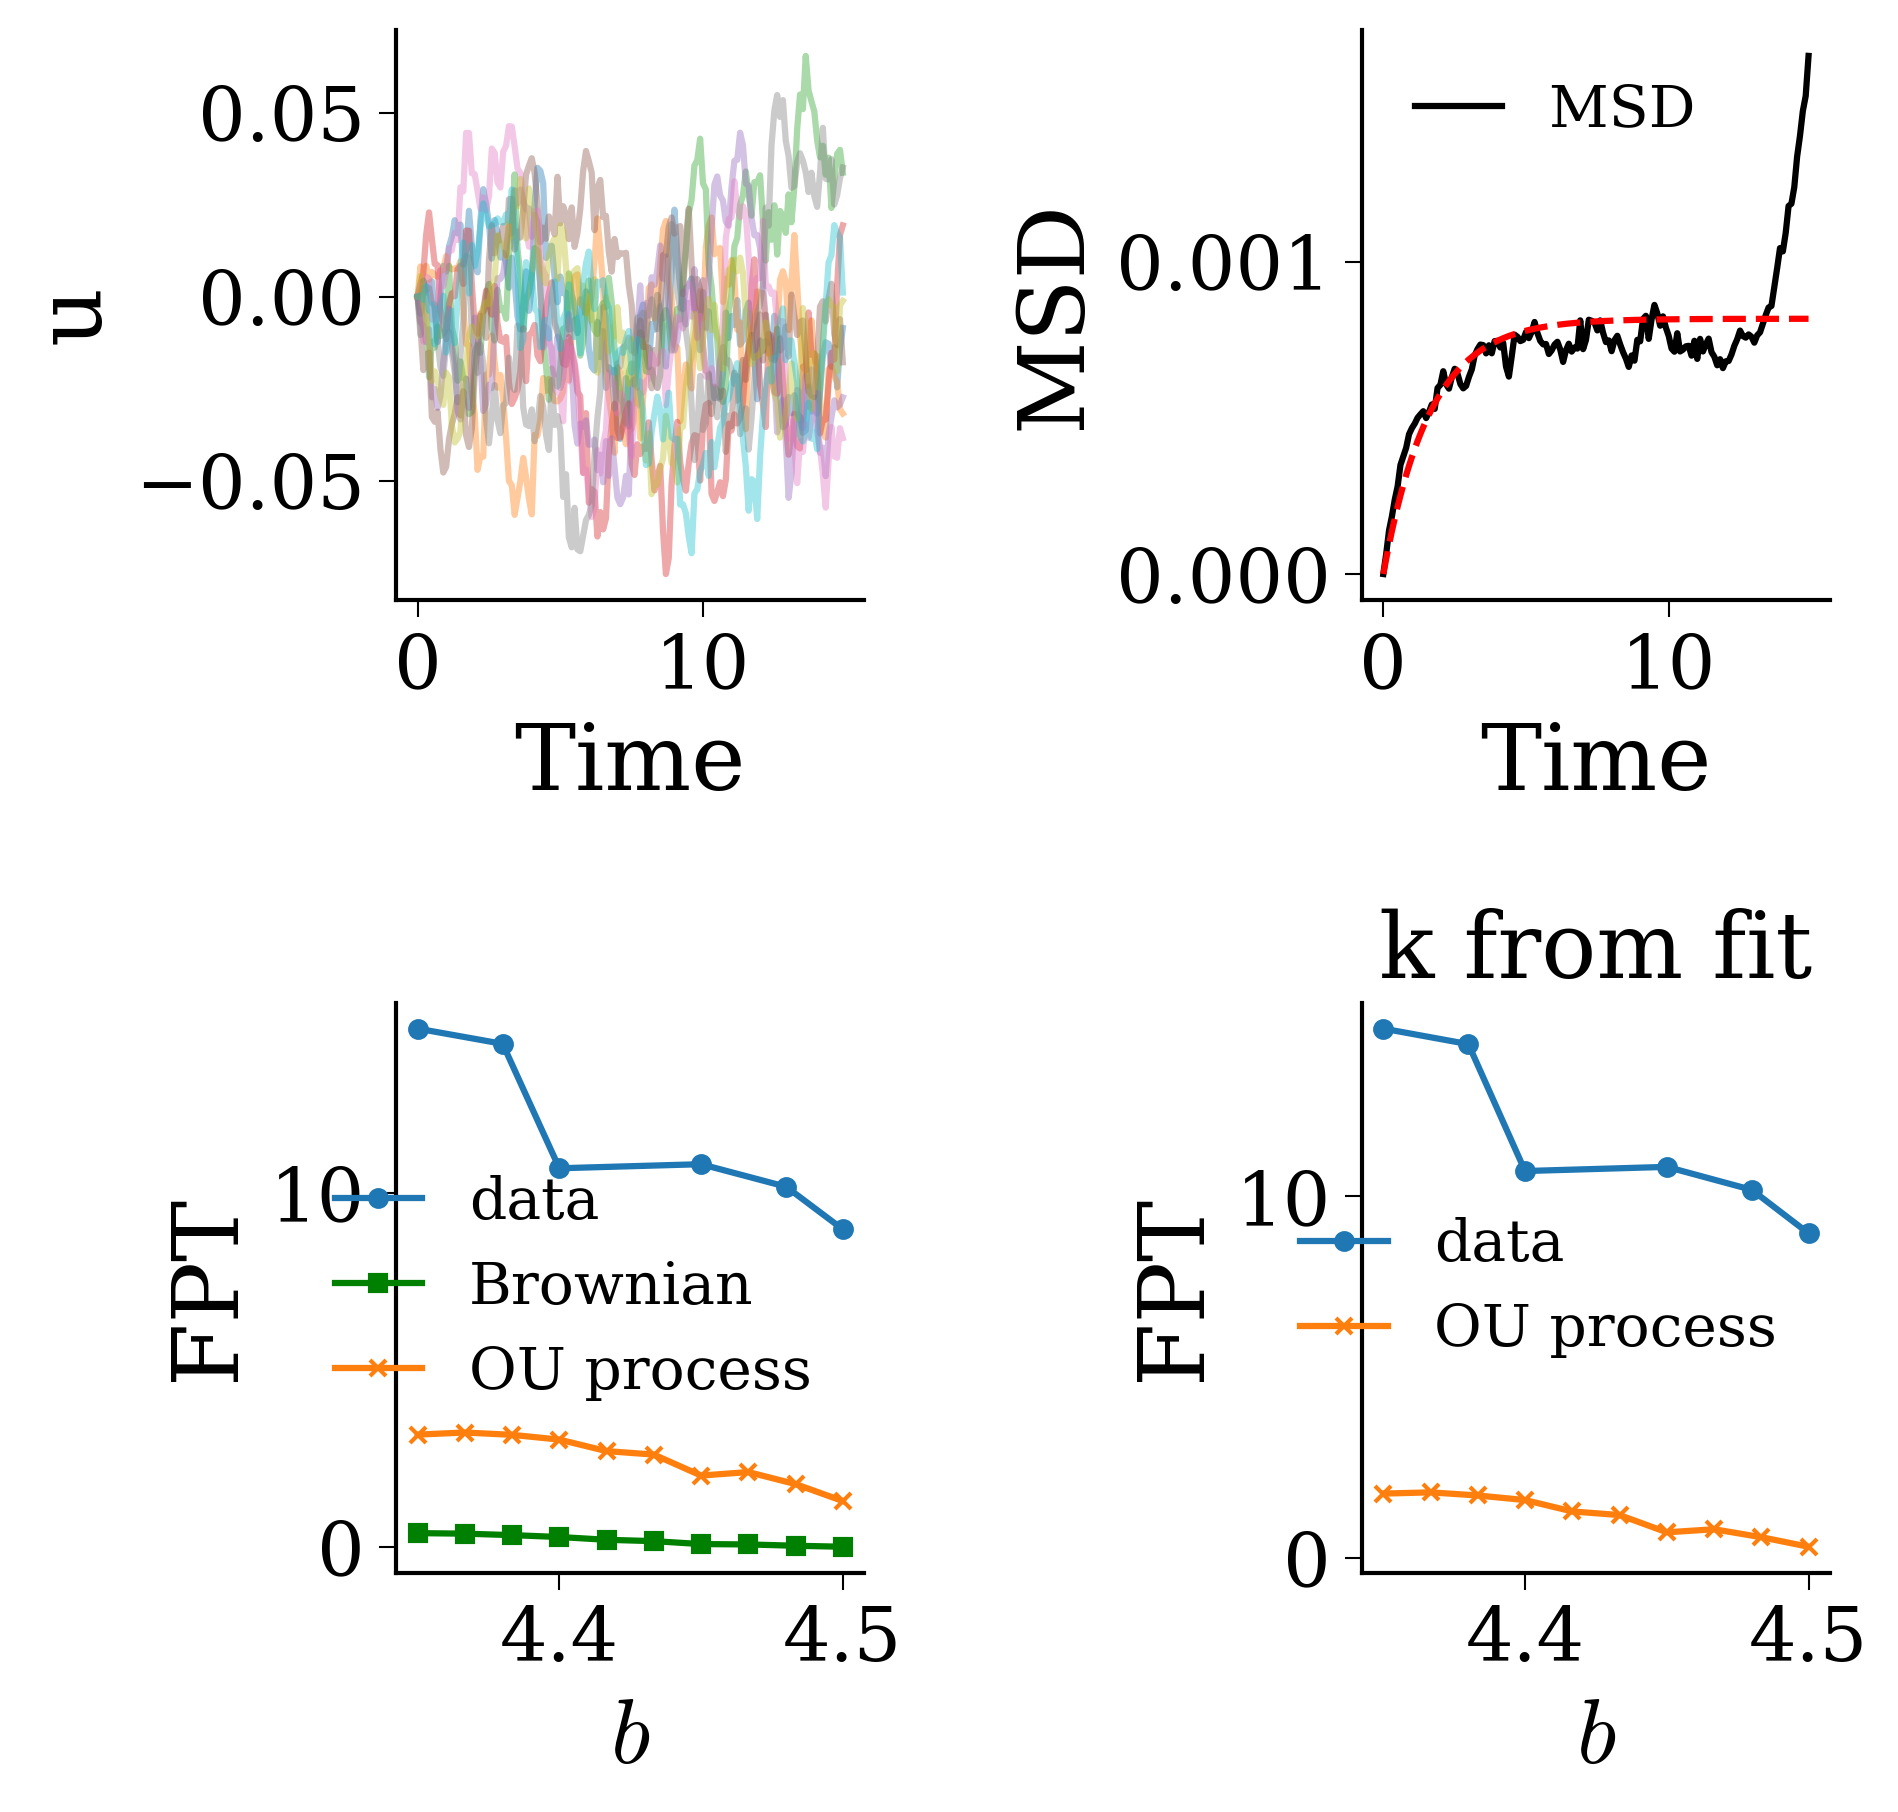

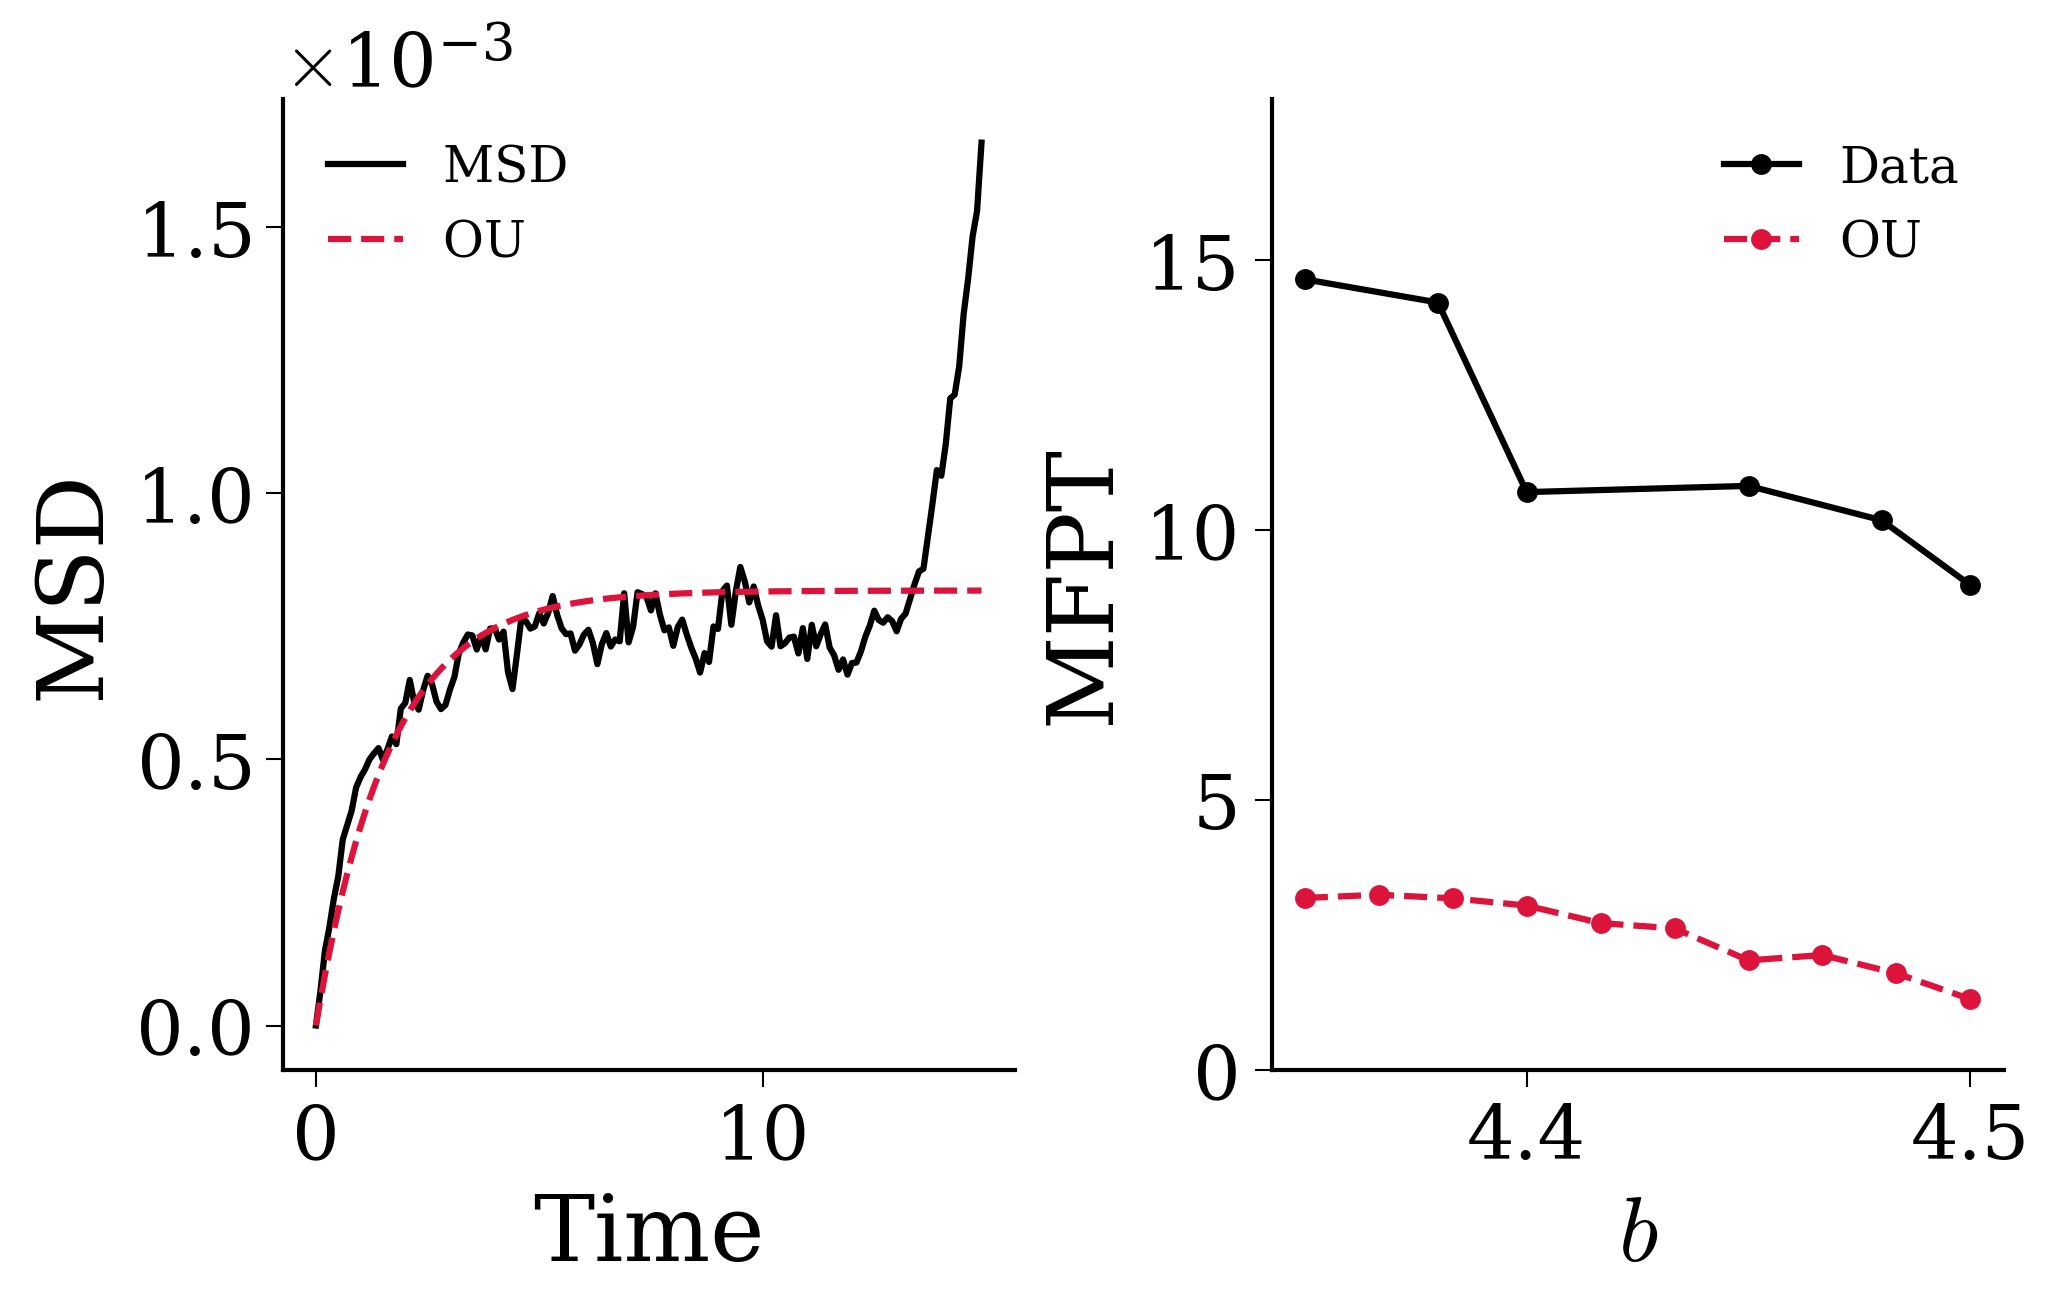

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')
import random
from scipy.stats import linregress
from scipy.optimize import curve_fit
import numba
from scipy.signal import savgol_filter
from scipy.stats import exponnorm

try:
    from numba import njit
    HAVE_NUMBA = True
except ImportError:
    HAVE_NUMBA = False
 
try:
    plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')
except OSError:
    pass

def parameters(a: float, b: float, c: float, d: float) -> dict:

    s_plus = (b*d**2+c*a**2)/(d*c*a)
    u_plus = c*a**2/(c*a**2+b*d**2)

    #coefficients computed as described in appendix C after substitution

    lambda4 = -b-a/s_plus -d*(1-2*u_plus) + c*s_plus**2*(2*u_plus - 3*u_plus**2)

    dup_sp = -a*(1-u_plus)/s_plus**2 + 2*c*s_plus*(u_plus**2 - u_plus**3)
    dup_um =(2*d + c*s_plus**2*(2 - 6*u_plus))/2

    detA = (lambda4*u_plus - s_plus*dup_sp)

    par = a/s_plus**2 + 2*c*s_plus*(2*u_plus -3*u_plus**2)

    alpha = lambda4 
    beta = -lambda4*par/(detA) + dup_sp*(c*s_plus**2*(2-6*u_plus) +2*d)/detA
    gamma = -c*s_plus**2 + par*s_plus*dup_um/detA - u_plus*dup_um*(c*s_plus**2*(2-6*u_plus)+2*d)/(detA)

    zeta = -d*(s_plus)
    eta = (lambda4*a/(s_plus**2) - d*dup_sp)/detA


    return dict(s_plus=s_plus, u_plus=u_plus, lambda_u=lambda4, alpha=alpha, beta=beta, gamma=gamma, zeta=zeta, eta=eta)

def initial_conditions(u0: float, s0: float, u_plus: float, s_plus: float) -> dict:

    x0 = (u0+u_plus)*(s0+s_plus)/2
    x1 = (u_plus-u0)*(s_plus-s0)/2
    y0 = (s0+s_plus)/2 - x0
    y1 = (s_plus-s0)/2 - x1

    return np.array([x0, y0, x1, y1])

def load_Gillespie_data(filename: str, omega: float) -> np.ndarray:
    """
    Load Gillespie simulation data from a binary file.
    The data is expected to be in the shape (6, N), where N is the number of time points.
    """
    data = np.fromfile(filename, dtype=np.float64).reshape(6, -1)
    V0 = data[4]
    RT = data[5]


    #traj = np.array([X01, X02, X11, X12])
    #traj_reduced = np.array([S_plus, S_minus, U_plus, U_minus])

    return RT,  V0

def rk4_step_det(state: np.ndarray, h: float,
             a: float, b: float, c: float, d: float, v0: float, omega: float) -> np.ndarray:
    k1 = f_det(state, a, b, c, d, v0, omega)
    k2 = f_det(state + 0.5 * h * k1, a, b, c, d, v0, omega)
    k3 = f_det(state + 0.5 * h * k2, a, b, c, d, v0, omega)
    k4 = f_det(state + h * k3, a, b, c, d, v0, omega)
    return state + h * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0

def f_det(state: np.ndarray, a: float, b: float, c: float, d: float, v0: float, omega: float) -> np.ndarray:
    x0, y0, x1, y1  = state

    #v1 = omega - v0
    v1 = omega - v0
    dx0 = a*v0 -(b+d)*x0 + c*x0**2*y0/(v0**2)
    dy0 = b*x0 - c*x0**2*y0/(v0**2)
    dx1 = a*v1 -(b+d)*x1 + c*x1**2*y1/(v1**2)
    dy1 = b*x1 - c*x1**2*y1/(v1**2)

    return np.array([dx0, dy0, dx1, dy1])

def f_noise(state: np.ndarray, a: float, b: float, c: float, d: float, v0: float, omega: float, rng: np.random.Generator) -> np.ndarray:
    x0, y0, x1, y1 = state
    v1 = omega - v0
    A1, A2, A3, A4 = a*v0, d*x0, b*x0, c*x0**2*y0/v0**2
    B1, B2, B3, B4 = a*v1, d*x1, b*x1, c*x1**2*y1/v1**2

    max_std = np.array([np.sqrt(A1)+np.sqrt(A2) + np.sqrt(A3) + np.sqrt(A4), np.sqrt(A3)+np.sqrt(A4), np.sqrt(B1)+np.sqrt(B2) + np.sqrt(B3) + np.sqrt(B4), np.sqrt(B3)+np.sqrt(B4)])

    dW = rng.normal(size=8) 
    dx0 = np.sqrt(A1)*dW[0] - np.sqrt(A2)*dW[1] - np.sqrt(A3)*dW[2] + np.sqrt(A4)*dW[3]
    dy0 = np.sqrt(A3)*dW[2] - np.sqrt(A4)*dW[3]
    dx1 = np.sqrt(B1)*dW[4] - np.sqrt(B2)*dW[5] - np.sqrt(B3)*dW[6] + np.sqrt(B4)*dW[7]
    dy1 = np.sqrt(B3)*dW[6] - np.sqrt(B4)*dW[7]
    return np.array([dx0, dy0, dx1, dy1]), max_std



def nullcline(s_arr: np.ndarray, lambda_u:float, beta:float, gamma:float) -> np.ndarray:
    """
    Analytical escape threshold |Delta u_-| as a function of s_-.
    Uses the rationalised form to remain numerically stable at s_- = 0.
    return both brances of the solution
    """

    disc = np.sqrt(beta * beta * s_arr * s_arr - 4.0 * gamma * lambda_u)
    return [(-beta *s_arr + disc) / (2.0 * gamma), (-beta * s_arr - disc) / (2.0 * gamma)]

def reduced_variables(traj: np.ndarray) -> np.ndarray:
    """
    Compute the reduced variables from the trajectory in ohysical variables.
    """
    s0 = traj[:,0] + traj[:,1]
    s1 = traj[:,2] + traj[:,3]
    u0 = (traj[:,0] / s0) /2
    u1 = (traj[:,2] / s1) /2
    sm = s0 - s1
    sp = s0 + s1
    um = u0 - u1
    up = u0 + u1
    return np.array([sp,up,sm,um])




def Gillespie_algorithm(ic, n_steps, a, b, c, d, Vol,T_max):
   

    x0, y0, x1, y1 = ic[0], ic[1], ic[2], ic[3]

    t_list = [0]
    traj_x0 = [x0]
    traj_y0 = [y0]
    traj_x1 = [x1]
    traj_y1 = [y1]

    t_cur = 0

    for _ in range(n_steps):
        s_tot = x0 + y0 + x1 + y1
        v0 = (x0 + y0) * Vol / s_tot
        v1 = Vol - v0

        # Propensities
        a1 = a * v0
        a2 = b * x0
        a3 = d * x0
        a4 = c * x0 * x0 * y0 / (v0 * v0)
        a5 = a * v1
        a6 = b * x1
        a7 = d * x1
        a8 = c * x1 * x1 * y1 / (v1 * v1)

        total_propensity = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8

        if total_propensity == 0.0:
            break

        # Time to next reaction
        tau = -np.log(np.random.random()) / total_propensity
        t_cur += tau

        # Determine which reaction occurs
        r = np.random.random() * total_propensity
        cum = a1
        if r < cum:
            reaction_index = 0
        else:
            cum += a2
            if r < cum:
                reaction_index = 1
            else:
                cum += a3
                if r < cum:
                    reaction_index = 2
                else:
                    cum += a4
                    if r < cum:
                        reaction_index = 3
                    else:
                        cum += a5
                        if r < cum:
                            reaction_index = 4
                        else:
                            cum += a6
                            if r < cum:
                                reaction_index = 5
                            else:
                                cum += a7
                                if r < cum:
                                    reaction_index = 6
                                else:
                                    reaction_index = 7

        if reaction_index == 0:
            x0 += 1
        elif reaction_index == 1:
            x0 -= 1
            y0 += 1
        elif reaction_index == 2:
            x0 -= 1
        elif reaction_index == 3:
            x0 += 1
            y0 -= 1
        elif reaction_index == 4:
            x1 += 1
        elif reaction_index == 5:
            x1 -= 1
            y1 += 1
        elif reaction_index == 6:
            x1 -= 1
        elif reaction_index == 7:
            x1 += 1
            y1 -= 1


        t_list.append(t_cur)
        traj_x0.append(x0)
        traj_y0.append(y0)
        traj_x1.append(x1)
        traj_y1.append(y1)
        if t_cur > T_max:
            break

    t = np.array(t_list)
    traj = np.column_stack((
    np.asarray(traj_x0),
    np.asarray(traj_y0),
    np.asarray(traj_x1),
    np.asarray(traj_y1),
    ))

    return t, traj

def compute_periods_vol(t, V,with_threshold = True):
    """
    Compute the periods of oscillation based on threshold crossings.
    """
    if with_threshold:
        V_smooth = savgol_filter(V, window_length=101, polyorder=3)
        dV = np.gradient(V_smooth, t)

        #
        thr =  0.09
        #thr = 0.45
        plateau = np.abs(dV) < thr

        change = np.diff(plateau.astype(int))

        starts = np.where(change == 1)[0] + 1
        ends   = np.where(change == -1)[0] + 1

        # casi limite
        if plateau[0]:
            starts = np.insert(starts, 0, 0)
        if plateau[-1]:
            ends = np.append(ends, len(plateau))

        periods = t[ends-1] - t[starts]
        periods = periods[periods > 3]
        periods = periods[periods < 80]

        return periods

    else:
        crossings = np.where(
            ((V[:-1] < 0.7) & (V[1:] >= 0.7)) |
            ((V[:-1] >= 0.7) & (V[1:] < 0.7))
        )[0] or np.where(
            ((V[:-1] < 0.3) & (V[1:] >= 0.3)) |
            ((V[:-1] >= 0.3) & (V[1:] < 0.3))
        )[0]

        t_cross = t[crossings]
        periods = np.diff(t_cross)
        periods = periods[periods > 4]
        
        return periods

def gillespie_to_threshold(x0, y0, x1, y1, a, b, c, d, Vol, T_max,
                            u_threshold, seed=None):
    
    rng = random.Random(seed)
    t_cur = 0.0
    u=[]
    t=[]
    while t_cur < T_max:
        s_tot = x0 + y0 + x1 + y1
        v0 = (x0 + y0) * Vol / s_tot
        v1 = Vol - v0
 
        a1 = a * v0
        a2 = b * x0
        a3 = d * x0
        a4 = c * x0 * x0 * y0 / (v0 * v0)
        a5 = a * v1
        a6 = b * x1
        a7 = d * x1
        a8 = c * x1 * x1 * y1 / (v1 * v1)
 
        a_tot = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8
        if a_tot <= 0.0:
            break
 
        tau = -np.log(rng.random()) / a_tot
        t_cur += tau
 
        r = rng.random() * a_tot
        c1 = a1
        c2 = c1 + a2
        c3 = c2 + a3
        c4 = c3 + a4
        c5 = c4 + a5
        c6 = c5 + a6
        c7 = c6 + a7
 
        if r < c1:
            x0 += 1
        elif r < c2:
            x0 -= 1; y0 += 1
        elif r < c3:
            x0 -= 1
        elif r < c4:
            x0 += 1; y0 -= 1
        elif r < c5:
            x1 += 1
        elif r < c6:
            x1 -= 1; y1 += 1
        elif r < c7:
            x1 -= 1
        else:
            x1 += 1; y1 -= 1
 
        u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
        u.append(u_now)
        t.append(t_cur)
        if u_now > u_threshold:
            return t, u

    else :
        return np.nan, np.nan
 

def msd_u(u_traj, t,):
    msd = np.zeros(len(t))
    u0 = u_traj[0]
    for index,u in enumerate(u_traj):
        msd[index] = (u-u0)**2

    slope, intercept, r, p, stderr = linregress(
            t,
            msd
        )

    D=slope/2
    return msd,D

if HAVE_NUMBA:
    @njit(cache=True, fastmath=True, nogil=True)
    def _gillespie_fixed_grid_core(x0, y0, x1, y1, a, b, c, d, Vol, T_max, dt_grid, seed):
        np.random.seed(seed)
        n_grid = int(T_max / dt_grid)
        t_eval = np.arange(n_grid) * dt_grid
        u_eval = np.zeros(n_grid)
        t_cur = 0.0
        idx = 0
        u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
 
        while t_cur < T_max and idx < n_grid:
            while idx < n_grid and t_eval[idx] <= t_cur:
                u_eval[idx] = u_now
                idx += 1
 
            s_tot = x0 + y0 + x1 + y1
            if s_tot <= 0:
                break
 
            v0 = (x0 + y0) * Vol / s_tot
            v1 = Vol - v0
 
            a1 = a * v0
            a2 = b * x0
            a3 = d * x0
            a4 = c * x0 * x0 * y0 / (v0 * v0) if v0 > 0 else 0.0
            a5 = a * v1
            a6 = b * x1
            a7 = d * x1
            a8 = c * x1 * x1 * y1 / (v1 * v1) if v1 > 0 else 0.0
 
            a_tot = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8
            if a_tot <= 0.0:
                break
 
            tau = -np.log(np.random.random()) / a_tot
            t_cur += tau
 
            r = np.random.random() * a_tot
            cum = a1
            if r < cum:
                x0 += 1
            else:
                cum += a2
                if r < cum:
                    x0 -= 1
                    y0 += 1
                else:
                    cum += a3
                    if r < cum:
                        x0 -= 1
                    else:
                        cum += a4
                        if r < cum:
                            x0 += 1
                            y0 -= 1
                        else:
                            cum += a5
                            if r < cum:
                                x1 += 1
                            else:
                                cum += a6
                                if r < cum:
                                    x1 -= 1
                                    y1 += 1
                                else:
                                    cum += a7
                                    if r < cum:
                                        x1 -= 1
                                    else:
                                        x1 += 1
                                        y1 -= 1
 
            u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
            if abs(u_now) > 0.1:
                return t_eval, u_eval, False
 
        while idx < n_grid:
            u_eval[idx] = u_now
            idx += 1
 
        return t_eval, u_eval, True
 
else:
    # Pure-Python fallback (identical logic, used only if numba isn't installed)
    def _gillespie_fixed_grid_core(x0, y0, x1, y1, a, b, c, d, Vol, T_max, dt_grid, seed):
        rng = random.Random(seed)
        n_grid = int(T_max / dt_grid)
        t_eval = np.arange(n_grid) * dt_grid
        u_eval = np.zeros(n_grid)
        t_cur = 0.0
        idx = 0
        u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
 
        while t_cur < T_max and idx < n_grid:
            while idx < n_grid and t_eval[idx] <= t_cur:
                u_eval[idx] = u_now
                idx += 1
 
            s_tot = x0 + y0 + x1 + y1
            if s_tot <= 0:
                break
 
            v0 = (x0 + y0) * Vol / s_tot
            v1 = Vol - v0
 
            a1 = a * v0
            a2 = b * x0
            a3 = d * x0
            a4 = c * x0 * x0 * y0 / (v0 * v0) if v0 > 0 else 0.0
            a5 = a * v1
            a6 = b * x1
            a7 = d * x1
            a8 = c * x1 * x1 * y1 / (v1 * v1) if v1 > 0 else 0.0
 
            a_tot = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8
            if a_tot <= 0.0:
                break
 
            tau = -np.log(rng.random()) / a_tot
            t_cur += tau
 
            r = rng.random() * a_tot
            cum = a1
            if r < cum:
                x0 += 1
            elif (cum := cum + a2) > r:
                x0 -= 1; y0 += 1
            elif (cum := cum + a3) > r:
                x0 -= 1
            elif (cum := cum + a4) > r:
                x0 += 1; y0 -= 1
            elif (cum := cum + a5) > r:
                x1 += 1
            elif (cum := cum + a6) > r:
                x1 -= 1; y1 += 1
            elif (cum := cum + a7) > r:
                x1 -= 1
            else:
                x1 += 1; y1 -= 1
 
            u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
            if abs(u_now) > 0.2:
                return t_eval, u_eval, False
 
        while idx < n_grid:
            u_eval[idx] = u_now
            idx += 1
 
        return t_eval, u_eval, True
 
 
def gillespie_fixed_grid(ic, a, b, c, d, Vol, T_max, dt_grid, seed):
    """Thin wrapper kept for API compatibility with the original script."""
    x0, y0, x1, y1 = ic
    t_eval, u_eval, valid = _gillespie_fixed_grid_core(
        float(x0), float(y0), float(x1), float(y1), a, b, c, d, Vol, T_max, dt_grid, seed
    )
    if not valid:
        return None, None
    return t_eval, u_eval

def OU_process_MSD(t,k,D):

    return 2*D*(1-np.exp(-k*t))/k


def compute_ensemble_msd(t_grid, trajectories,):
  
    u0 = trajectories[:, 0][:, np.newaxis]
    sq_displacements = (trajectories[:] - u0) ** 2
    
    msd_ensemble = np.mean(sq_displacements, axis=0)
    
    popt, pcov = curve_fit(OU_process_MSD, t_grid[1:], msd_ensemble[1:], p0=[1, 1])
    k, D = popt

    #res = linregress(t_grid[1:], msd_ensemble[1:])
    #D = res.slope / 2.0
    
    #return msd_ensemble, D, res.rvalue**2
    return msd_ensemble, D, k

def run_ensemble(ic, a, b, c, d, Vol, T, dt_grid, N_traj, max_workers=None, base_seed=0):
   
    max_workers = max_workers or os.cpu_count() or 1
    trajectories = []
    t_grid = None
    first_plotted = []
 
    if HAVE_NUMBA:
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = {
                ex.submit(gillespie_fixed_grid, ic.copy(), a, b, c, d, Vol, T, dt_grid, base_seed + i): i
                for i in range(N_traj)
            }
            for fut in as_completed(futures):
                i = futures[fut]
                t_eval, u_traj = fut.result()
                if u_traj is not None:
                    t_grid = t_eval
                    trajectories.append((i, u_traj))
    else:
        for i in range(N_traj):
            t_eval, u_traj = gillespie_fixed_grid(ic.copy(), a, b, c, d, Vol, T, dt_grid, base_seed + i)
            if u_traj is not None:
                t_grid = t_eval
                trajectories.append((i, u_traj))
 
    # keep original trajectory order (irrelevant for the ensemble average,
    # but nice for the "first 10 trajectories" preview plot)
    trajectories.sort(key=lambda p: p[0])
    ordered = [u for _, u in trajectories]
    return t_grid, np.array(ordered)

def _hyp2F2_1123(z):
    """2F2(1, 1; 3/2, 2; z)"""
    return mp.hyper([1, 1], [mp.mpf(3)/2, 2], z)

def u(x, eps, mu, alpha, beta):
    """
    u(x) = -x^2/eps^2 * 2F2(1,1;3/2,2; mu/eps^2 * x^2)
           + 1/eps^2 * erfi(sqrt(mu)/eps * x) *
             [alpha^2 * 2F2(1,1;3/2,2; mu/eps^2*alpha^2) - beta^2 * 2F2(1,1;3/2,2; mu/eps^2*beta^2)]
             / [erfi(sqrt(mu)/eps*alpha) - erfi(sqrt(mu)/eps*beta)]
           + 1/eps^2 *
             [beta^2 * 2F2(1,1;3/2,2; mu/eps^2*beta^2) * erfi(sqrt(mu)/eps*alpha)
              - alpha^2 * 2F2(1,1;3/2,2; mu/eps^2*alpha^2) * erfi(sqrt(mu)/eps*beta)]
             / [erfi(sqrt(mu)/eps*alpha) - erfi(sqrt(mu)/eps*beta)]

    Parameters
    ----------
    x : float or array-like
    eps, mu, alpha, beta : float
        Scalar parameters of the profile.

    Returns
    -------
    float or np.ndarray of floats
    """
    eps, mu, alpha, beta = map(mp.mpf, (eps, mu, alpha, beta))
    sqrt_mu = mp.sqrt(mu)

    # terms that only depend on the fixed parameters (computed once)
    F_alpha = _hyp2F2_1123(mu / eps**2 * alpha**2)
    F_beta  = _hyp2F2_1123(mu / eps**2 * beta**2)
    erfi_alpha = mp.erfi(sqrt_mu / eps * alpha)
    erfi_beta  = mp.erfi(sqrt_mu / eps * beta)
    denom = erfi_alpha - erfi_beta

    num2 = alpha**2 * F_alpha - beta**2 * F_beta
    num3 = beta**2 * F_beta * erfi_alpha - alpha**2 * F_alpha * erfi_beta

    def _u_scalar(xi):
        xi = mp.mpf(xi)
        term1 = -xi**2 / eps**2 * _hyp2F2_1123(mu / eps**2 * xi**2)
        term2 = (1 / eps**2) * mp.erfi(sqrt_mu / eps * xi) * num2 / denom
        term3 = (1 / eps**2) * num3 / denom
        return float(term1 + term2 + term3)

    if np.isscalar(x):
        return _u_scalar(x)
    return np.array([_u_scalar(xi) for xi in np.atleast_1d(x)])

def main() -> None:
    b_arr = np.linspace(4.35, 4.5, 10)
    a, b, c, d = 2.0, 4.45, 1.0, 1.0
    D_arr = []
    k_arr = []
    time_brown = []
          
    T = 15.0          
    dt_grid = 0.1    
    time_arr = []
    Vol = 5000
    N_traj = 1000 
    n_workers = os.cpu_count() or 1
    fig, ax = plt.subplots(2, 2, figsize=(6.75, 6.5))
    for b in b_arr:
        a, c, d = 2.0, 1.0, 1.0
        coeffs = parameters(a, b, c, d)        
        ic = initial_conditions(0.0, 3.5, coeffs['u_plus'], coeffs['s_plus']) * Vol
        t_grid, trajectories = run_ensemble(ic, a, b, c, d, Vol, T, dt_grid, N_traj, max_workers=n_workers)
        lambda_u = coeffs['lambda_u']
        msd, D, k = compute_ensemble_msd(t_grid, trajectories, )

        print(f"b = {b:.2f}, D = {D:.6e} (k = {k:.4f}), (k/lambda = {k/coeffs['lambda_u']:.4f})")

        time = u(0, np.sqrt(2*D), k, nullcline(3.5, lambda_u, coeffs['beta'], coeffs['gamma'])[0], nullcline(3.5, lambda_u, coeffs['beta'], coeffs['gamma'])[1])
        k_arr.append(time)

        time = u(0, np.sqrt(2*D), -lambda_u, nullcline(3.5, lambda_u, coeffs['beta'], coeffs['gamma'])[0], nullcline(3.5, lambda_u, coeffs['beta'], coeffs['gamma'])[1])
        time_arr.append(time)

        time = (nullcline(3.5, lambda_u, coeffs['beta'], coeffs['gamma'])[0])**2/(2*D)
        time_brown.append(time)

        if b == 4.45:
            for u_traj in trajectories[:10]:
                ax[0,0].plot(t_grid, u_traj, alpha=0.4)
    ax[0,0].set_xlabel('Time')
    ax[0,0].set_ylabel('u')
  

    ax[0,1].plot(t_grid, msd, 'k-', label='MSD ', lw=1.5)
    ax[0,1].plot(t_grid, OU_process_MSD(t_grid, k, D), 'r--', )
    ax[0,1].set_xlabel('Time')
    ax[0,1].set_ylabel('MSD')
    ax[0,1].legend()

    b_arr_file = [4.35, 4.38, 4.4 ,4.45,4.48, 4.5 ]

    arr_mean = []
    path = '../../b_diff/'
    data_file = path + np.array(['data_gil_4.35.bin','data_gil_4.38.bin', 'data_gil_4.4.bin','data_gil_4.45.bin','data_gil_4.48.bin','data_gil_4.5.bin'])
    for filename in data_file:
        t_G, V0_G = load_Gillespie_data(filename, Vol)
        periods_G = compute_periods_vol(t_G, V0_G, with_threshold=True )    
        K, mu, sigma = exponnorm.fit(periods_G)
        mean =  K * sigma
        arr_mean.append(mean)

    ax[1,0].plot(b_arr_file, arr_mean, marker='o', label='data')
    ax[1,0].plot(b_arr, time_brown, color='green', marker='s', label='Brownian')
    ax[1,0].plot(b_arr, np.array(time_arr), marker='x', label='OU process')
    ax[1,0].set_xlabel('$b$')
    ax[1,0].set_ylabel('FPT')
    ax[1,1].set_title('lambda')
    ax[1,0].legend()

    ax[1,1].plot(b_arr_file, arr_mean, marker='o', label='data')
    ax[1,1].plot(b_arr, np.array(k_arr), marker='x', label='OU process')
    ax[1,1].set_xlabel('$b$')
    ax[1,1].set_ylabel('FPT')
    ax[1,1].set_title('k from fit')
    ax[1,1].legend()

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(6.75, 4.25))
    ax[0].plot(t_grid, msd, 'k-', label='MSD ',)
    ax[0].plot(t_grid, OU_process_MSD(t_grid, k, D), label='OU ' ,color= 'crimson', ls='--',)
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('MSD')
    ax[0].ticklabel_format(style='sci',axis='y',scilimits=(0, 0),useMathText=True)
    ax[0].legend(fontsize=12)

    ax[1].plot(b_arr_file, arr_mean,color = 'black',ls='-', marker='o', label='Data')
    ax[1].plot(b_arr, np.array(time_arr),color = 'crimson',ls='--',marker='o',label='OU')
    ax[1].set_xlabel('$b$')
    ax[1].set_ylabel('MFPT')
    ax[1].set_ylim([0, 18])
    ax[1].legend(fontsize=12)

    fig.savefig("Fig3/OU_comparison.png", )
    plt.show()
if __name__ == "__main__":
    main()

b = 4.35, D = 1.379925e-04 (k = 0.2873), (k/lambda = -1.6807)
b = 4.37, D = 1.962037e-04 (k = 0.4804), (k/lambda = -3.0947)
b = 4.38, D = 1.976495e-04 (k = 0.4893), (k/lambda = -3.5065)
b = 4.40, D = 2.054469e-04 (k = 0.5135), (k/lambda = -4.1477)
b = 4.42, D = 1.675269e-04 (k = 0.3795), (k/lambda = -3.5110)
b = 4.43, D = 1.848135e-04 (k = 0.4378), (k/lambda = -4.7406)
b = 4.45, D = 2.223985e-04 (k = 0.5362), (k/lambda = -6.9973)
b = 4.47, D = 1.996019e-04 (k = 0.4571), (k/lambda = -7.5064)
b = 4.48, D = 2.054068e-04 (k = 0.4571), (k/lambda = -10.1234)
b = 4.50, D = 2.422360e-04 (k = 0.5728), (k/lambda = -19.4739)


/Users/lhc642/Documents/Phd/Brusselator/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/Users/lhc642/Documents/Phd/Brusselator/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/lhc642/Documents/Phd/Brusselator/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/lhc642/Documents/Phd/Brusselator/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/lhc642/Documents/Phd/Brusselator/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/User

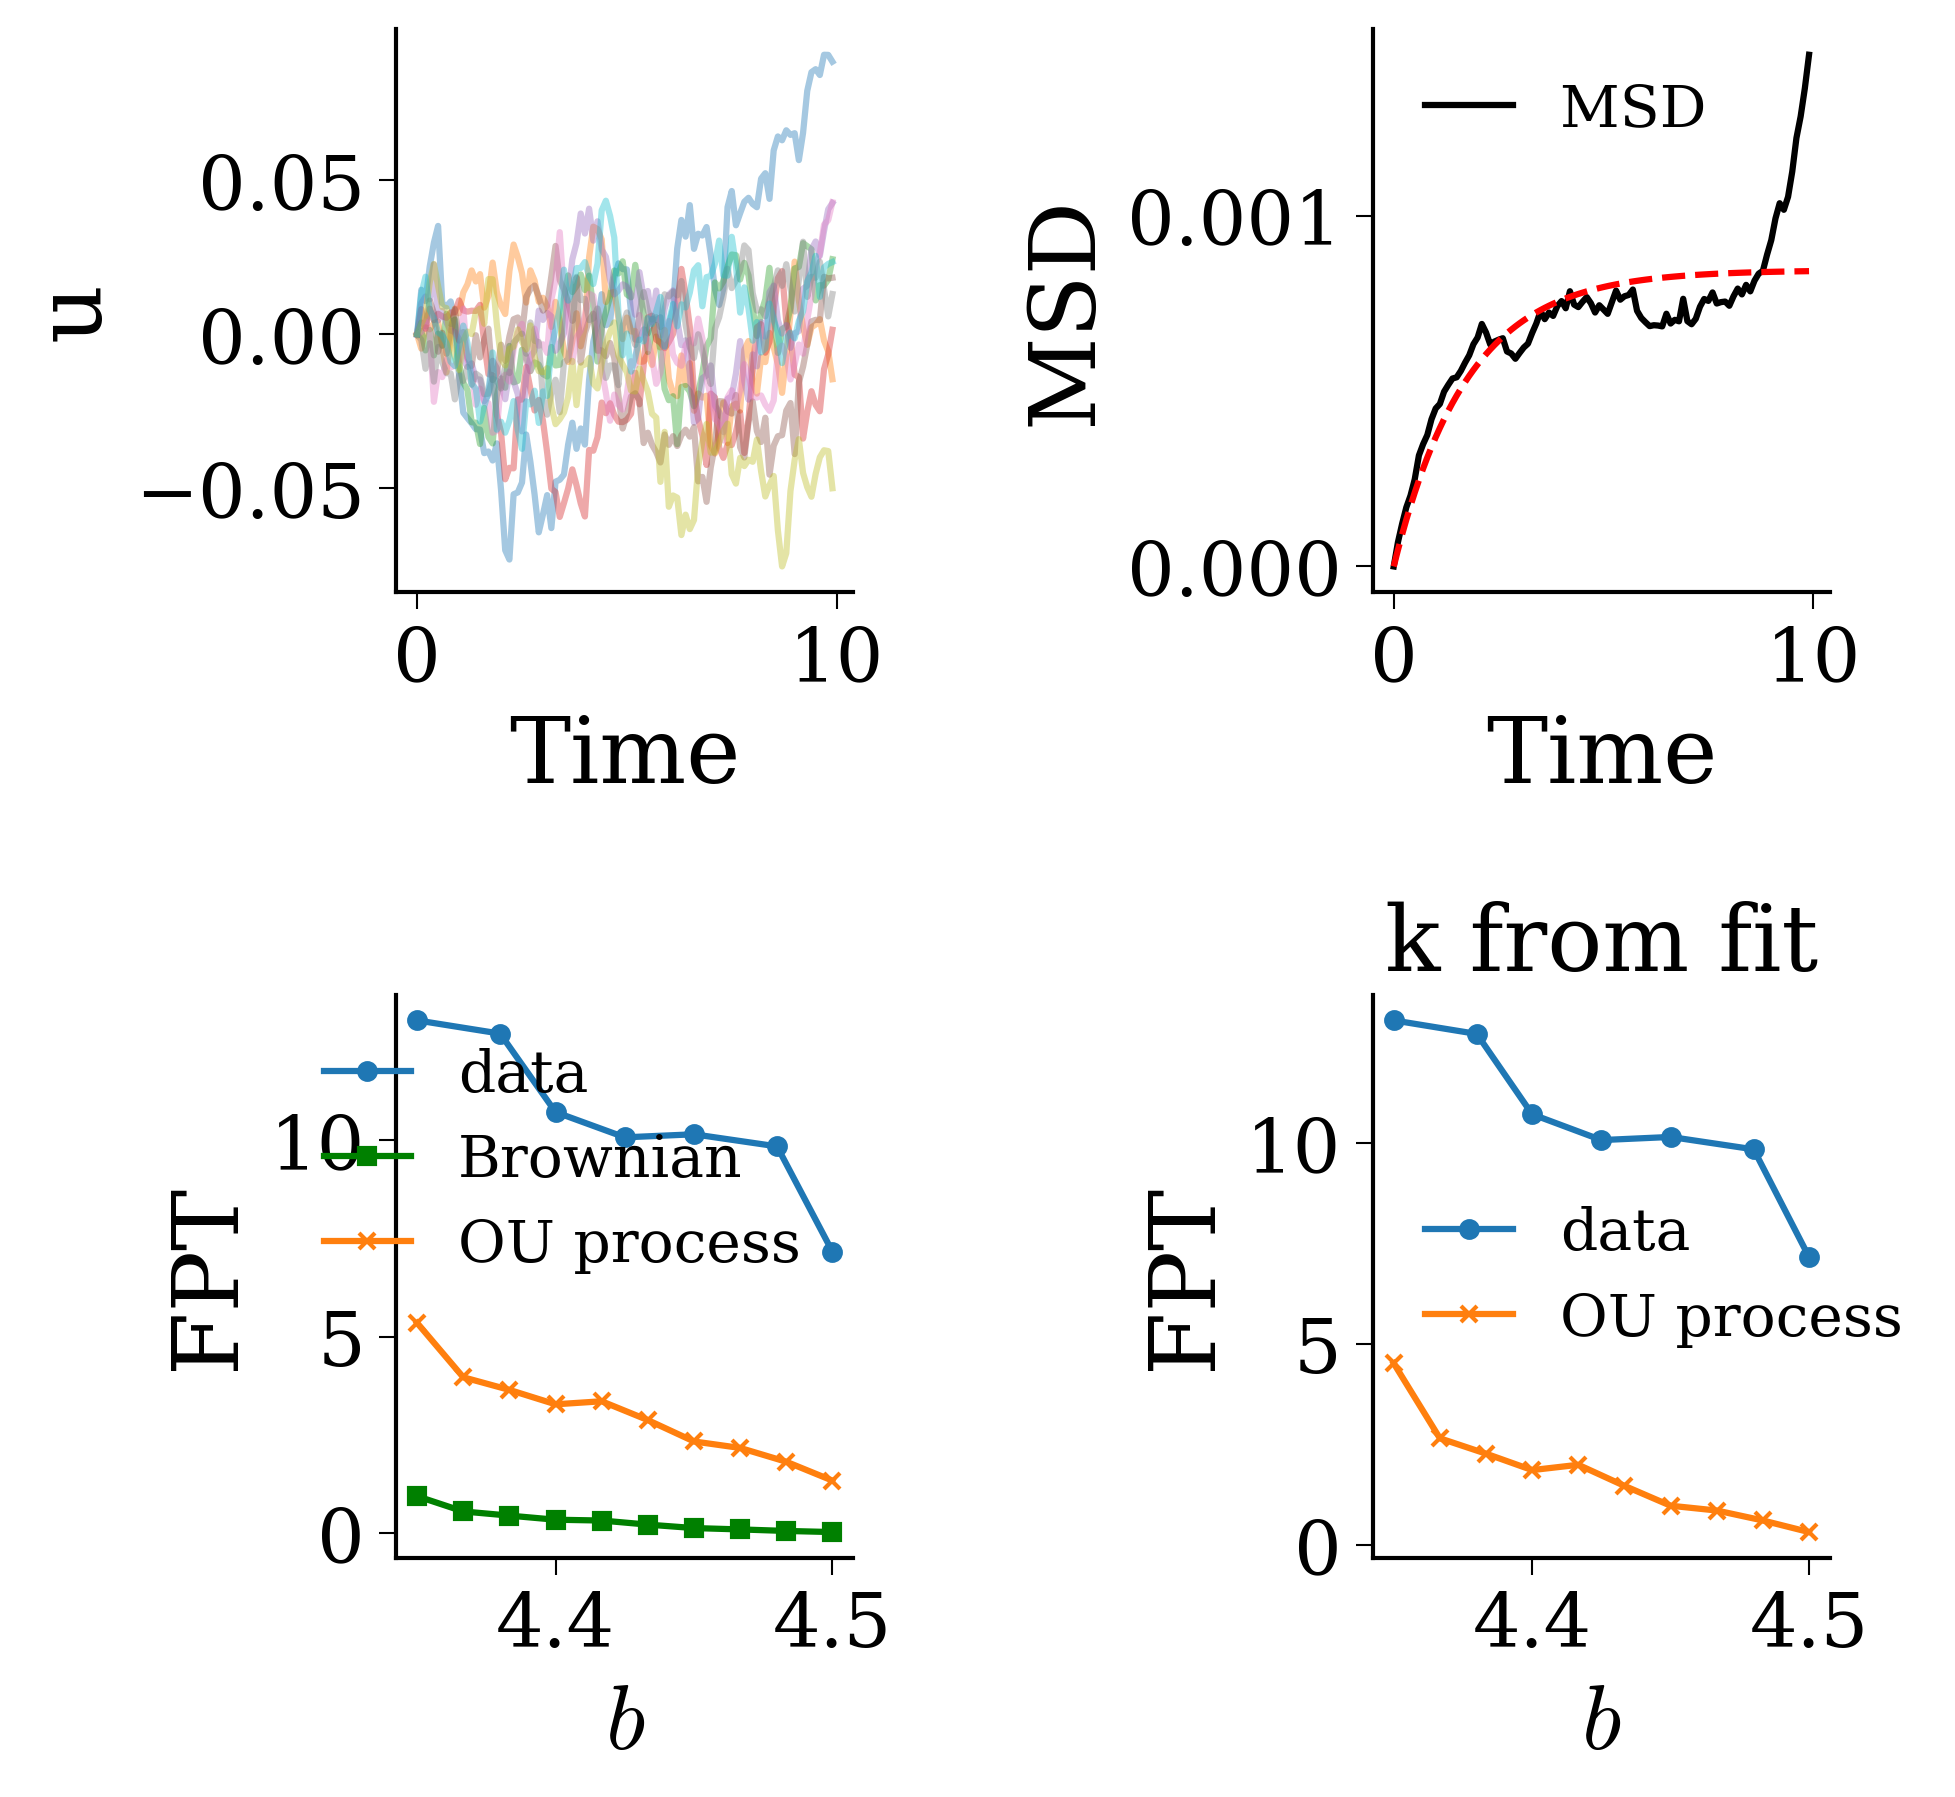

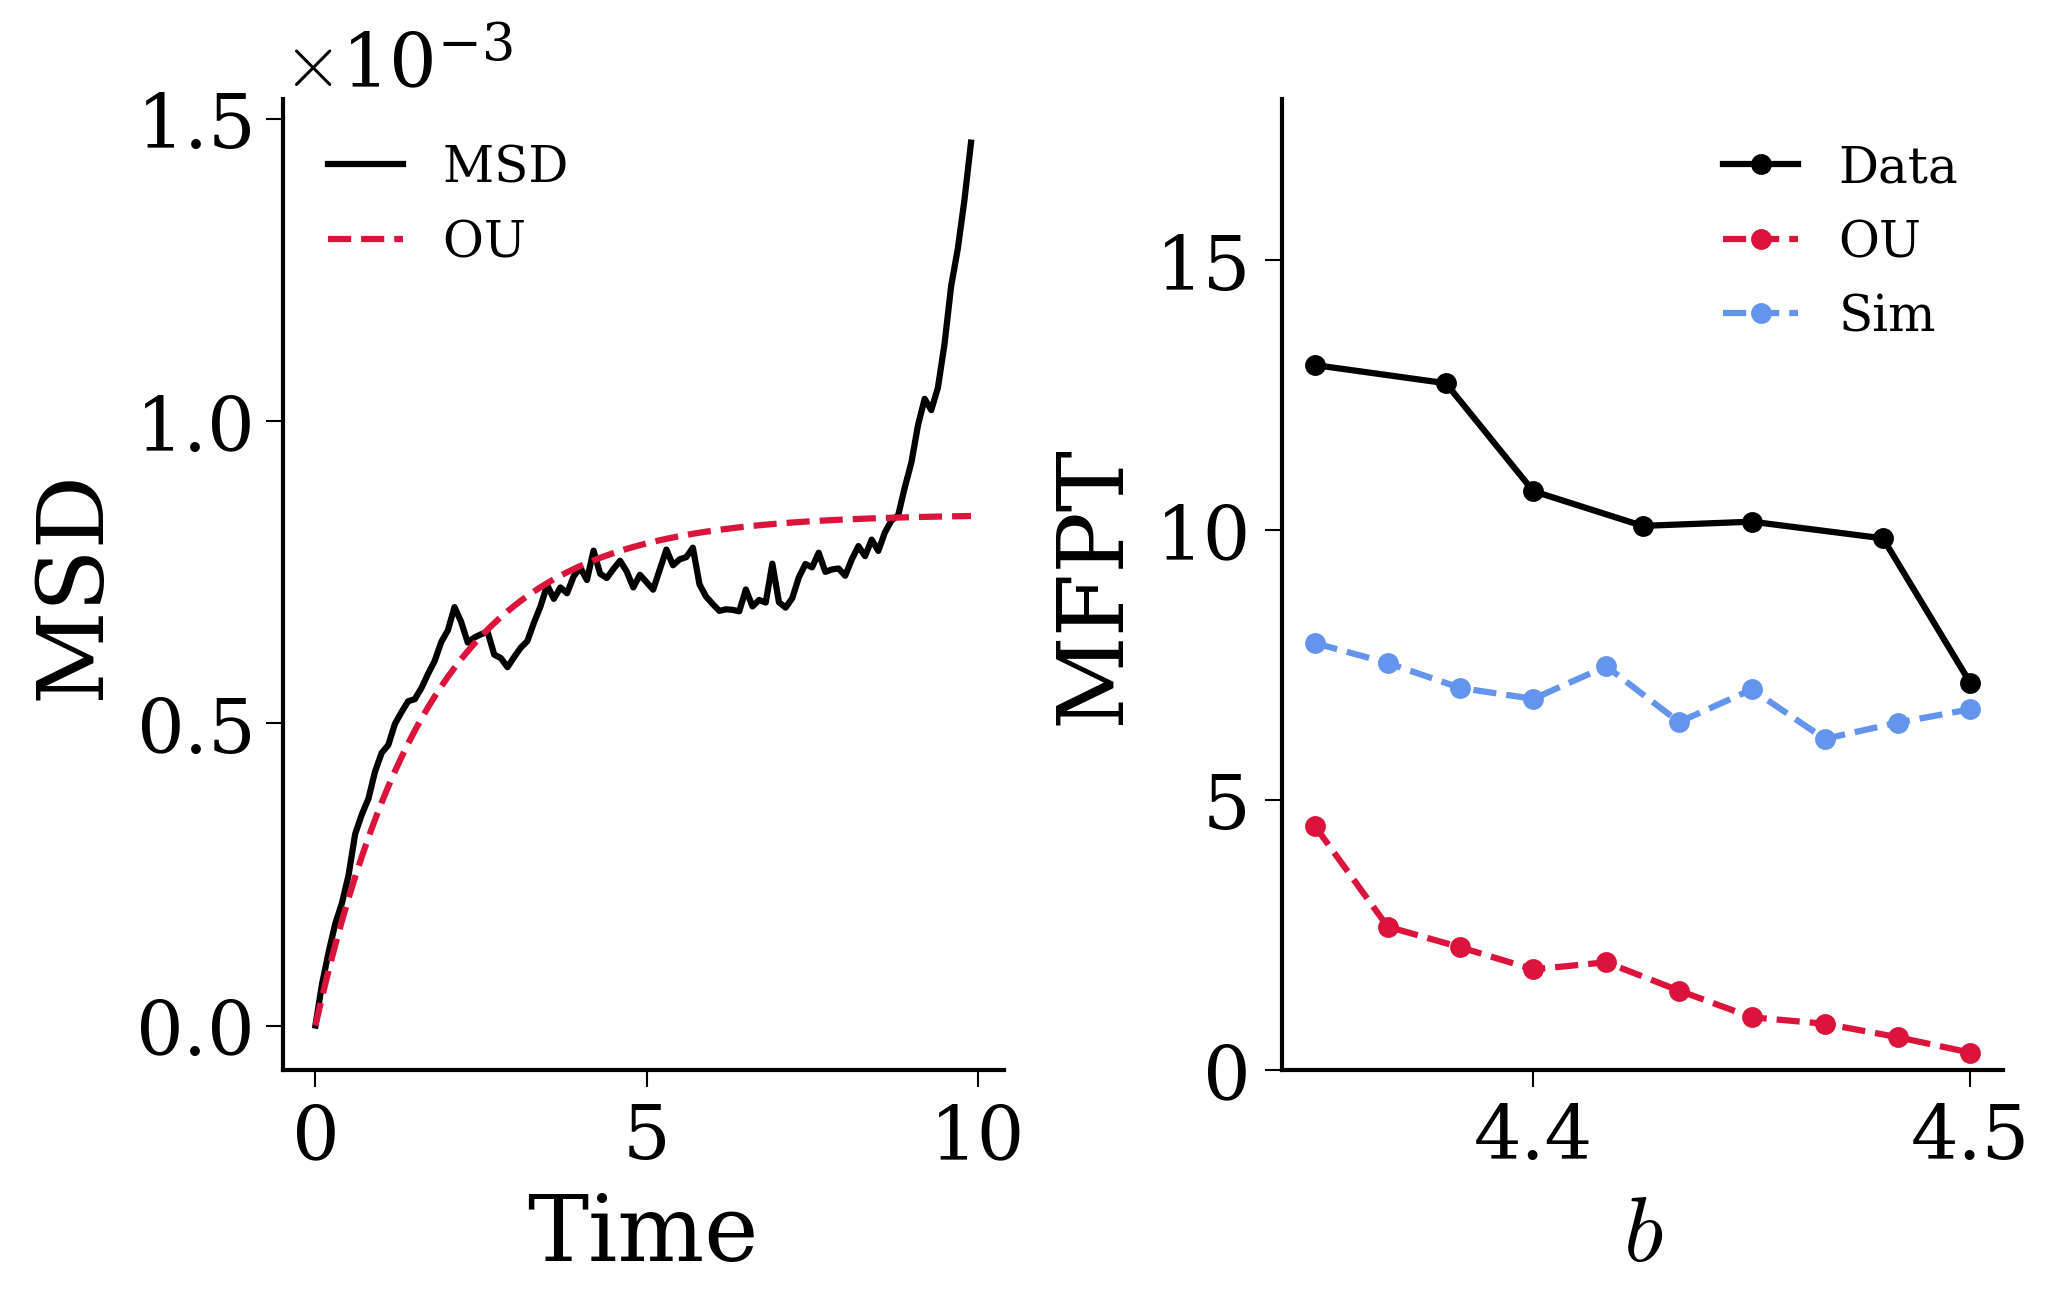

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')
import random
from scipy.stats import linregress
from scipy.optimize import curve_fit
import numba
from scipy.signal import savgol_filter
from scipy.stats import exponnorm

try:
    from numba import njit
    HAVE_NUMBA = True
except ImportError:
    HAVE_NUMBA = False
 
try:
    plt.style.use('/Users/lhc642/.config/matplotlib/stylelib/PRE_2col.mplstyle')
except OSError:
    pass

def parameters(a: float, b: float, c: float, d: float) -> dict:

    s_plus = (b*d**2+c*a**2)/(d*c*a)
    u_plus = c*a**2/(c*a**2+b*d**2)

    #coefficients computed as described in appendix C after substitution

    lambda4 = -b-a/s_plus -d*(1-2*u_plus) + c*s_plus**2*(2*u_plus - 3*u_plus**2)

    dup_sp = -a*(1-u_plus)/s_plus**2 + 2*c*s_plus*(u_plus**2 - u_plus**3)
    dup_um =(2*d + c*s_plus**2*(2 - 6*u_plus))/2

    detA = (lambda4*u_plus - s_plus*dup_sp)

    par = a/s_plus**2 + 2*c*s_plus*(2*u_plus -3*u_plus**2)

    alpha = lambda4 
    beta = -lambda4*par/(detA) + dup_sp*(c*s_plus**2*(2-6*u_plus) +2*d)/detA
    gamma = -c*s_plus**2 + par*s_plus*dup_um/detA - u_plus*dup_um*(c*s_plus**2*(2-6*u_plus)+2*d)/(detA)

    zeta = -d*(s_plus)
    eta = (lambda4*a/(s_plus**2) - d*dup_sp)/detA


    return dict(s_plus=s_plus, u_plus=u_plus, lambda_u=lambda4, alpha=alpha, beta=beta, gamma=gamma, zeta=zeta, eta=eta)

def initial_conditions(u0: float, s0: float, u_plus: float, s_plus: float) -> dict:

    x0 = (u0+u_plus)*(s0+s_plus)/2
    x1 = (u_plus-u0)*(s_plus-s0)/2
    y0 = (s0+s_plus)/2 - x0
    y1 = (s_plus-s0)/2 - x1

    return np.array([x0, y0, x1, y1])

def load_Gillespie_data(filename: str, omega: float) -> np.ndarray:
    """
    Load Gillespie simulation data from a binary file.
    The data is expected to be in the shape (6, N), where N is the number of time points.
    """
    data = np.fromfile(filename, dtype=np.float64).reshape(6, -1)
    V0 = data[4]
    RT = data[5]


    #traj = np.array([X01, X02, X11, X12])
    #traj_reduced = np.array([S_plus, S_minus, U_plus, U_minus])

    return RT,  V0

def rk4_step_det(state: np.ndarray, h: float,
             a: float, b: float, c: float, d: float, v0: float, omega: float) -> np.ndarray:
    k1 = f_det(state, a, b, c, d, v0, omega)
    k2 = f_det(state + 0.5 * h * k1, a, b, c, d, v0, omega)
    k3 = f_det(state + 0.5 * h * k2, a, b, c, d, v0, omega)
    k4 = f_det(state + h * k3, a, b, c, d, v0, omega)
    return state + h * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0

def f_det(state: np.ndarray, a: float, b: float, c: float, d: float, v0: float, omega: float) -> np.ndarray:
    x0, y0, x1, y1  = state

    #v1 = omega - v0
    v1 = omega - v0
    dx0 = a*v0 -(b+d)*x0 + c*x0**2*y0/(v0**2)
    dy0 = b*x0 - c*x0**2*y0/(v0**2)
    dx1 = a*v1 -(b+d)*x1 + c*x1**2*y1/(v1**2)
    dy1 = b*x1 - c*x1**2*y1/(v1**2)

    return np.array([dx0, dy0, dx1, dy1])

def f_noise(state: np.ndarray, a: float, b: float, c: float, d: float, v0: float, omega: float, rng: np.random.Generator) -> np.ndarray:
    x0, y0, x1, y1 = state
    v1 = omega - v0
    A1, A2, A3, A4 = a*v0, d*x0, b*x0, c*x0**2*y0/v0**2
    B1, B2, B3, B4 = a*v1, d*x1, b*x1, c*x1**2*y1/v1**2

    max_std = np.array([np.sqrt(A1)+np.sqrt(A2) + np.sqrt(A3) + np.sqrt(A4), np.sqrt(A3)+np.sqrt(A4), np.sqrt(B1)+np.sqrt(B2) + np.sqrt(B3) + np.sqrt(B4), np.sqrt(B3)+np.sqrt(B4)])

    dW = rng.normal(size=8) 
    dx0 = np.sqrt(A1)*dW[0] - np.sqrt(A2)*dW[1] - np.sqrt(A3)*dW[2] + np.sqrt(A4)*dW[3]
    dy0 = np.sqrt(A3)*dW[2] - np.sqrt(A4)*dW[3]
    dx1 = np.sqrt(B1)*dW[4] - np.sqrt(B2)*dW[5] - np.sqrt(B3)*dW[6] + np.sqrt(B4)*dW[7]
    dy1 = np.sqrt(B3)*dW[6] - np.sqrt(B4)*dW[7]
    return np.array([dx0, dy0, dx1, dy1]), max_std



def nullcline(s_arr: np.ndarray, lambda_u:float, beta:float, gamma:float) -> np.ndarray:
    """
    Analytical escape threshold |Delta u_-| as a function of s_-.
    Uses the rationalised form to remain numerically stable at s_- = 0.
    return both brances of the solution
    """

    disc = np.sqrt(beta * beta * s_arr * s_arr - 4.0 * gamma * lambda_u)
    return [(-beta *s_arr + disc) / (2.0 * gamma), (-beta * s_arr - disc) / (2.0 * gamma)]

def reduced_variables(traj: np.ndarray) -> np.ndarray:
    """
    Compute the reduced variables from the trajectory in ohysical variables.
    """
    s0 = traj[:,0] + traj[:,1]
    s1 = traj[:,2] + traj[:,3]
    u0 = (traj[:,0] / s0) /2
    u1 = (traj[:,2] / s1) /2
    sm = s0 - s1
    sp = s0 + s1
    um = u0 - u1
    up = u0 + u1
    return np.array([sp,up,sm,um])




def Gillespie_algorithm(ic, n_steps, a, b, c, d, Vol,T_max):
   

    x0, y0, x1, y1 = ic[0], ic[1], ic[2], ic[3]

    t_list = [0]
    traj_x0 = [x0]
    traj_y0 = [y0]
    traj_x1 = [x1]
    traj_y1 = [y1]

    t_cur = 0

    for _ in range(n_steps):
        s_tot = x0 + y0 + x1 + y1
        v0 = (x0 + y0) * Vol / s_tot
        v1 = Vol - v0

        # Propensities
        a1 = a * v0
        a2 = b * x0
        a3 = d * x0
        a4 = c * x0 * x0 * y0 / (v0 * v0)
        a5 = a * v1
        a6 = b * x1
        a7 = d * x1
        a8 = c * x1 * x1 * y1 / (v1 * v1)

        total_propensity = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8

        if total_propensity == 0.0:
            break

        # Time to next reaction
        tau = -np.log(np.random.random()) / total_propensity
        t_cur += tau

        # Determine which reaction occurs
        r = np.random.random() * total_propensity
        cum = a1
        if r < cum:
            reaction_index = 0
        else:
            cum += a2
            if r < cum:
                reaction_index = 1
            else:
                cum += a3
                if r < cum:
                    reaction_index = 2
                else:
                    cum += a4
                    if r < cum:
                        reaction_index = 3
                    else:
                        cum += a5
                        if r < cum:
                            reaction_index = 4
                        else:
                            cum += a6
                            if r < cum:
                                reaction_index = 5
                            else:
                                cum += a7
                                if r < cum:
                                    reaction_index = 6
                                else:
                                    reaction_index = 7

        if reaction_index == 0:
            x0 += 1
        elif reaction_index == 1:
            x0 -= 1
            y0 += 1
        elif reaction_index == 2:
            x0 -= 1
        elif reaction_index == 3:
            x0 += 1
            y0 -= 1
        elif reaction_index == 4:
            x1 += 1
        elif reaction_index == 5:
            x1 -= 1
            y1 += 1
        elif reaction_index == 6:
            x1 -= 1
        elif reaction_index == 7:
            x1 += 1
            y1 -= 1


        t_list.append(t_cur)
        traj_x0.append(x0)
        traj_y0.append(y0)
        traj_x1.append(x1)
        traj_y1.append(y1)
        if t_cur > T_max:
            break

    t = np.array(t_list)
    traj = np.column_stack((
    np.asarray(traj_x0),
    np.asarray(traj_y0),
    np.asarray(traj_x1),
    np.asarray(traj_y1),
    ))

    return t, traj

def compute_periods_vol(t, V,with_threshold = True):
    """
    Compute the periods of oscillation based on threshold crossings.
    """
    if with_threshold:
        V_smooth = savgol_filter(V, window_length=101, polyorder=3)
        dV = np.gradient(V_smooth, t)

        #
        thr =  0.09
        #thr = 0.45
        plateau = np.abs(dV) < thr

        change = np.diff(plateau.astype(int))

        starts = np.where(change == 1)[0] + 1
        ends   = np.where(change == -1)[0] + 1

        # casi limite
        if plateau[0]:
            starts = np.insert(starts, 0, 0)
        if plateau[-1]:
            ends = np.append(ends, len(plateau))

        periods = t[ends-1] - t[starts]
        periods = periods[periods > 3]
        periods = periods[periods < 80]

        return periods

    else:
        crossings = np.where(
            ((V[:-1] < 0.7) & (V[1:] >= 0.7)) |
            ((V[:-1] >= 0.7) & (V[1:] < 0.7))
        )[0] or np.where(
            ((V[:-1] < 0.3) & (V[1:] >= 0.3)) |
            ((V[:-1] >= 0.3) & (V[1:] < 0.3))
        )[0]

        t_cross = t[crossings]
        periods = np.diff(t_cross)
        periods = periods[periods > 4]
        
        return periods

def gillespie_to_threshold(x0, y0, x1, y1, a, b, c, d, Vol, T_max,
                            u_threshold, seed=None):
    
    rng = random.Random(seed)
    t_cur = 0.0
    u=[]
    t=[]
    while t_cur < T_max:
        s_tot = x0 + y0 + x1 + y1
        v0 = (x0 + y0) * Vol / s_tot
        v1 = Vol - v0
 
        a1 = a * v0
        a2 = b * x0
        a3 = d * x0
        a4 = c * x0 * x0 * y0 / (v0 * v0)
        a5 = a * v1
        a6 = b * x1
        a7 = d * x1
        a8 = c * x1 * x1 * y1 / (v1 * v1)
 
        a_tot = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8
        if a_tot <= 0.0:
            break
 
        tau = -np.log(rng.random()) / a_tot
        t_cur += tau
 
        r = rng.random() * a_tot
        c1 = a1
        c2 = c1 + a2
        c3 = c2 + a3
        c4 = c3 + a4
        c5 = c4 + a5
        c6 = c5 + a6
        c7 = c6 + a7
 
        if r < c1:
            x0 += 1
        elif r < c2:
            x0 -= 1; y0 += 1
        elif r < c3:
            x0 -= 1
        elif r < c4:
            x0 += 1; y0 -= 1
        elif r < c5:
            x1 += 1
        elif r < c6:
            x1 -= 1; y1 += 1
        elif r < c7:
            x1 -= 1
        else:
            x1 += 1; y1 -= 1
 
        u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
        u.append(u_now)
        t.append(t_cur)
        if u_now > u_threshold:
            return t, u

    else :
        return np.nan, np.nan
 

def msd_u(u_traj, t,):
    msd = np.zeros(len(t))
    u0 = u_traj[0]
    for index,u in enumerate(u_traj):
        msd[index] = (u-u0)**2

    slope, intercept, r, p, stderr = linregress(
            t,
            msd
        )

    D=slope/2
    return msd,D

if HAVE_NUMBA:
    @njit(cache=True, fastmath=True, nogil=True)
    def _gillespie_fixed_grid_core(x0, y0, x1, y1, a, b, c, d, Vol, T_max, dt_grid, seed):
        np.random.seed(seed)
        n_grid = int(T_max / dt_grid)
        t_eval = np.arange(n_grid) * dt_grid
        u_eval = np.zeros(n_grid)
        t_cur = 0.0
        idx = 0
        u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
 
        while t_cur < T_max and idx < n_grid:
            while idx < n_grid and t_eval[idx] <= t_cur:
                u_eval[idx] = u_now
                idx += 1
 
            s_tot = x0 + y0 + x1 + y1
            if s_tot <= 0:
                break
 
            v0 = (x0 + y0) * Vol / s_tot
            v1 = Vol - v0
 
            a1 = a * v0
            a2 = b * x0
            a3 = d * x0
            a4 = c * x0 * x0 * y0 / (v0 * v0) if v0 > 0 else 0.0
            a5 = a * v1
            a6 = b * x1
            a7 = d * x1
            a8 = c * x1 * x1 * y1 / (v1 * v1) if v1 > 0 else 0.0
 
            a_tot = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8
            if a_tot <= 0.0:
                break
 
            tau = -np.log(np.random.random()) / a_tot
            t_cur += tau
 
            r = np.random.random() * a_tot
            cum = a1
            if r < cum:
                x0 += 1
            else:
                cum += a2
                if r < cum:
                    x0 -= 1
                    y0 += 1
                else:
                    cum += a3
                    if r < cum:
                        x0 -= 1
                    else:
                        cum += a4
                        if r < cum:
                            x0 += 1
                            y0 -= 1
                        else:
                            cum += a5
                            if r < cum:
                                x1 += 1
                            else:
                                cum += a6
                                if r < cum:
                                    x1 -= 1
                                    y1 += 1
                                else:
                                    cum += a7
                                    if r < cum:
                                        x1 -= 1
                                    else:
                                        x1 += 1
                                        y1 -= 1
 
            u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
            #if abs(u_now) > 0.1:
            if abs(u_now) > 0.1:
                return t_eval, u_eval, False
 
        while idx < n_grid:
            u_eval[idx] = u_now
            idx += 1
 
        return t_eval, u_eval, True
 
else:
    # Pure-Python fallback (identical logic, used only if numba isn't installed)
    def _gillespie_fixed_grid_core(x0, y0, x1, y1, a, b, c, d, Vol, T_max, dt_grid, seed):
        rng = random.Random(seed)
        n_grid = int(T_max / dt_grid)
        t_eval = np.arange(n_grid) * dt_grid
        u_eval = np.zeros(n_grid)
        t_cur = 0.0
        idx = 0
        u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
 
        while t_cur < T_max and idx < n_grid:
            while idx < n_grid and t_eval[idx] <= t_cur:
                u_eval[idx] = u_now
                idx += 1
 
            s_tot = x0 + y0 + x1 + y1
            if s_tot <= 0:
                break
 
            v0 = (x0 + y0) * Vol / s_tot
            v1 = Vol - v0
 
            a1 = a * v0
            a2 = b * x0
            a3 = d * x0
            a4 = c * x0 * x0 * y0 / (v0 * v0) if v0 > 0 else 0.0
            a5 = a * v1
            a6 = b * x1
            a7 = d * x1
            a8 = c * x1 * x1 * y1 / (v1 * v1) if v1 > 0 else 0.0
 
            a_tot = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8
            if a_tot <= 0.0:
                break
 
            tau = -np.log(rng.random()) / a_tot
            t_cur += tau
 
            r = rng.random() * a_tot
            cum = a1
            if r < cum:
                x0 += 1
            elif (cum := cum + a2) > r:
                x0 -= 1; y0 += 1
            elif (cum := cum + a3) > r:
                x0 -= 1
            elif (cum := cum + a4) > r:
                x0 += 1; y0 -= 1
            elif (cum := cum + a5) > r:
                x1 += 1
            elif (cum := cum + a6) > r:
                x1 -= 1; y1 += 1
            elif (cum := cum + a7) > r:
                x1 -= 1
            else:
                x1 += 1; y1 -= 1
 
            u_now = 0.5 * x0 / (x0 + y0) - 0.5 * x1 / (x1 + y1)
            #if abs(u_now) > 0.1:
            if abs(u_now) > 0.6:
                return t_eval, u_eval, False
 
        while idx < n_grid:
            u_eval[idx] = u_now
            idx += 1
 
        return t_eval, u_eval, True
 
 
def gillespie_fixed_grid(ic, a, b, c, d, Vol, T_max, dt_grid, seed):
    """Thin wrapper kept for API compatibility with the original script."""
    x0, y0, x1, y1 = ic
    t_eval, u_eval, valid = _gillespie_fixed_grid_core(
        float(x0), float(y0), float(x1), float(y1), a, b, c, d, Vol, T_max, dt_grid, seed
    )
    if not valid:
        return None, None
    return t_eval, u_eval

def OU_process_MSD(t,k,D):
    """MSD of the Ornstein-Uhlenbeck process: MSD(t) = 2*D*(1-exp(-k*t))/k"""
    return 2*D*(1-np.exp(-k*t))/k


def compute_ensemble_msd(t_grid, trajectories,):
  
    u0 = trajectories[:, 0][:, np.newaxis]
    sq_displacements = (trajectories[:] - u0) ** 2
    
    msd_ensemble = np.mean(sq_displacements, axis=0)
    
    popt, pcov = curve_fit(OU_process_MSD, t_grid[1:], msd_ensemble[1:], p0=[1, 1])
    k, D = popt

    #res = linregress(t_grid[1:], msd_ensemble[1:])
    #D = res.slope / 2.0
    
    #return msd_ensemble, D, res.rvalue**2
    return msd_ensemble, D, k

def run_ensemble(ic, a, b, c, d, Vol, T, dt_grid, N_traj, max_workers=None, base_seed=0):
   
    max_workers = max_workers or os.cpu_count() or 1
    trajectories = []
    t_grid = None
    first_plotted = []
 
    if HAVE_NUMBA:
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = {
                ex.submit(gillespie_fixed_grid, ic.copy(), a, b, c, d, Vol, T, dt_grid, base_seed + i): i
                for i in range(N_traj)
            }
            for fut in as_completed(futures):
                i = futures[fut]
                t_eval, u_traj = fut.result()
                if u_traj is not None:
                    t_grid = t_eval
                    trajectories.append((i, u_traj))
    else:
        for i in range(N_traj):
            t_eval, u_traj = gillespie_fixed_grid(ic.copy(), a, b, c, d, Vol, T, dt_grid, base_seed + i)
            if u_traj is not None:
                t_grid = t_eval
                trajectories.append((i, u_traj))
 
    # keep original trajectory order (irrelevant for the ensemble average,
    # but nice for the "first 10 trajectories" preview plot)
    trajectories.sort(key=lambda p: p[0])
    ordered = [u for _, u in trajectories]
    return t_grid, np.array(ordered)

def _hyp2F2_1123(z):
    """2F2(1, 1; 3/2, 2; z)"""
    return mp.hyper([1, 1], [mp.mpf(3)/2, 2], z)


if HAVE_NUMBA:
    @njit(cache=True, fastmath=True, nogil=True)
    def _gillespie_to_switch_core(x0, y0, x1, y1, a, b, c, d, Vol, T_max, seed):
        np.random.seed(seed)
        t_cur = 0.0

        s_tot0 = x0 + y0 + x1 + y1
        v0_0 = (x0 + y0) * Vol / s_tot0
        v1_0 = Vol - v0_0
        sign0 = v0_0 < v1_0   # segno di riferimento, fissato all'inizio

        while t_cur < T_max:
            s_tot = x0 + y0 + x1 + y1
            if s_tot <= 0:
                break

            v0 = (x0 + y0) * Vol / s_tot
            v1 = Vol - v0

            a1 = a * v0
            a2 = b * x0
            a3 = d * x0
            a4 = c * x0 * x0 * y0 / (v0 * v0) if v0 > 0 else 0.0
            a5 = a * v1
            a6 = b * x1
            a7 = d * x1
            a8 = c * x1 * x1 * y1 / (v1 * v1) if v1 > 0 else 0.0

            a_tot = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8
            if a_tot <= 0.0:
                break

            tau = -np.log(np.random.random()) / a_tot
            t_cur += tau

            r = np.random.random() * a_tot
            cum = a1
            if r < cum:
                x0 += 1
            else:
                cum += a2
                if r < cum:
                    x0 -= 1; y0 += 1
                else:
                    cum += a3
                    if r < cum:
                        x0 -= 1
                    else:
                        cum += a4
                        if r < cum:
                            x0 += 1; y0 -= 1
                        else:
                            cum += a5
                            if r < cum:
                                x1 += 1
                            else:
                                cum += a6
                                if r < cum:
                                    x1 -= 1; y1 += 1
                                else:
                                    cum += a7
                                    if r < cum:
                                        x1 -= 1
                                    else:
                                        x1 += 1; y1 -= 1

            s_tot_now = x0 + y0 + x1 + y1
            if s_tot_now <= 0:
                break
            v0_now = (x0 + y0) * Vol / s_tot_now
            v1_now = Vol - v0_now
            sign_now = v0_now < v1_now

            if sign_now != sign0:
                return t_cur, True

        return t_cur, False

else:
    def _gillespie_to_switch_core(x0, y0, x1, y1, a, b, c, d, Vol, T_max, seed):
        rng = random.Random(seed)
        t_cur = 0.0

        s_tot0 = x0 + y0 + x1 + y1
        v0_0 = (x0 + y0) * Vol / s_tot0
        v1_0 = Vol - v0_0
        sign0 = v0_0 < v1_0

        while t_cur < T_max:
            s_tot = x0 + y0 + x1 + y1
            if s_tot <= 0:
                break

            v0 = (x0 + y0) * Vol / s_tot
            v1 = Vol - v0

            a1 = a * v0
            a2 = b * x0
            a3 = d * x0
            a4 = c * x0 * x0 * y0 / (v0 * v0) if v0 > 0 else 0.0
            a5 = a * v1
            a6 = b * x1
            a7 = d * x1
            a8 = c * x1 * x1 * y1 / (v1 * v1) if v1 > 0 else 0.0

            a_tot = a1 + a2 + a3 + a4 + a5 + a6 + a7 + a8
            if a_tot <= 0.0:
                break

            tau = -np.log(rng.random()) / a_tot
            t_cur += tau

            r = rng.random() * a_tot
            cum = a1
            if r < cum:
                x0 += 1
            elif (cum := cum + a2) > r:
                x0 -= 1; y0 += 1
            elif (cum := cum + a3) > r:
                x0 -= 1
            elif (cum := cum + a4) > r:
                x0 += 1; y0 -= 1
            elif (cum := cum + a5) > r:
                x1 += 1
            elif (cum := cum + a6) > r:
                x1 -= 1; y1 += 1
            elif (cum := cum + a7) > r:
                x1 -= 1
            else:
                x1 += 1; y1 -= 1

            s_tot_now = x0 + y0 + x1 + y1
            if s_tot_now <= 0:
                break
            v0_now = (x0 + y0) * Vol / s_tot_now
            v1_now = Vol - v0_now
            sign_now = v0_now < v1_now

            if sign_now != sign0:
                return t_cur, True

        return t_cur, False


def gillespie_to_volume_switch(ic, a, b, c, d, Vol, T_max, seed):

    x0, y0, x1, y1 = ic
    t_cur, switched = _gillespie_to_switch_core(
        float(x0), float(y0), float(x1), float(y1), a, b, c, d, Vol, T_max, seed
    )
    return t_cur if switched else np.nan


def run_ensemble_switch_times(ic, a, b, c, d, Vol, T_max, N_traj,
                               max_workers=None, base_seed=0):

    max_workers = max_workers or os.cpu_count() or 1
    times = []

    if HAVE_NUMBA:
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [
                ex.submit(gillespie_to_volume_switch, ic.copy(), a, b, c, d, Vol, T_max, base_seed + i)
                for i in range(N_traj)
            ]
            for fut in as_completed(futures):
                t = fut.result()
                if not np.isnan(t):
                    times.append(t)
    else:
        for i in range(N_traj):
            t = gillespie_to_volume_switch(ic.copy(), a, b, c, d, Vol, T_max, base_seed + i)
            if not np.isnan(t):
                times.append(t)

    return np.asarray(times)

def u(x, eps, mu, alpha, beta):
    """
    u(x) = -x^2/eps^2 * 2F2(1,1;3/2,2; mu/eps^2 * x^2)
           + 1/eps^2 * erfi(sqrt(mu)/eps * x) *
             [alpha^2 * 2F2(1,1;3/2,2; mu/eps^2*alpha^2) - beta^2 * 2F2(1,1;3/2,2; mu/eps^2*beta^2)]
             / [erfi(sqrt(mu)/eps*alpha) - erfi(sqrt(mu)/eps*beta)]
           + 1/eps^2 *
             [beta^2 * 2F2(1,1;3/2,2; mu/eps^2*beta^2) * erfi(sqrt(mu)/eps*alpha)
              - alpha^2 * 2F2(1,1;3/2,2; mu/eps^2*alpha^2) * erfi(sqrt(mu)/eps*beta)]
             / [erfi(sqrt(mu)/eps*alpha) - erfi(sqrt(mu)/eps*beta)]

    Parameters
    ----------
    x : float or array-like
    eps, mu, alpha, beta : float
        Scalar parameters of the profile.

    Returns
    -------
    float or np.ndarray of floats
    """
    eps, mu, alpha, beta = map(mp.mpf, (eps, mu, alpha, beta))
    sqrt_mu = mp.sqrt(mu)

    # terms that only depend on the fixed parameters (computed once)
    F_alpha = _hyp2F2_1123(mu / eps**2 * alpha**2)
    F_beta  = _hyp2F2_1123(mu / eps**2 * beta**2)
    erfi_alpha = mp.erfi(sqrt_mu / eps * alpha)
    erfi_beta  = mp.erfi(sqrt_mu / eps * beta)
    denom = erfi_alpha - erfi_beta

    num2 = alpha**2 * F_alpha - beta**2 * F_beta
    num3 = beta**2 * F_beta * erfi_alpha - alpha**2 * F_alpha * erfi_beta

    def _u_scalar(xi):
        xi = mp.mpf(xi)
        term1 = -xi**2 / eps**2 * _hyp2F2_1123(mu / eps**2 * xi**2)
        term2 = (1 / eps**2) * mp.erfi(sqrt_mu / eps * xi) * num2 / denom
        term3 = (1 / eps**2) * num3 / denom
        return float(term1 + term2 + term3)

    if np.isscalar(x):
        return _u_scalar(x)
    return np.array([_u_scalar(xi) for xi in np.atleast_1d(x)])


def estimate_transition_rate(tau_samples, tail_fraction=0.3):

    tau = np.sort(np.asarray(tau_samples)) #discard last 10 values to avoid outliers
    n = len(tau)
    survival = 1.0 - np.arange(1, n + 1) / n   

    cut = int(n * (1 - tail_fraction))
    t_tail = tau[cut:-1]
    s_tail = survival[cut:-1]
    s_tail = np.clip(s_tail, 1e-300, None)    

    slope, intercept = np.polyfit(t_tail, np.log(s_tail), 1)
    rate = -slope
    tau_transition = 1.0 / rate               

    return tau_transition, rate,intercept, (t_tail, s_tail)

def main() -> None:
    b_arr = np.linspace(4.35, 4.5, 10)
    a, b, c, d = 2.0, 4.45, 1.0, 1.0
    D_arr = []
    arr_period_sim = []
    k_arr = []
    time_brown = []
          
    T = 10.0          
    dt_grid = 0.1    
    time_arr = []
    Vol = 5000
    N_traj = 1000 
    n_workers = os.cpu_count() or 1
    fig, ax = plt.subplots(2, 2, figsize=(6.75, 6.5))
    for b in b_arr:
        a, c, d = 2.0, 1.0, 1.0
        coeffs = parameters(a, b, c, d)        
        ic = initial_conditions(0.0, 3.5, coeffs['u_plus'], coeffs['s_plus']) * Vol
        t_grid, trajectories = run_ensemble(ic, a, b, c, d, Vol, T, dt_grid, N_traj, max_workers=n_workers)
        lambda_u = coeffs['lambda_u']
        msd, D, k = compute_ensemble_msd(t_grid, trajectories, )

        periods = run_ensemble_switch_times(ic, a, b, c, d, Vol, 100, N_traj, max_workers=n_workers, base_seed=0)
        tau_transition, rate, intercept, tail_data = estimate_transition_rate(periods, tail_fraction=0.2)
        arr_period_sim.append(tau_transition)

        print(f"b = {b:.2f}, D = {D:.6e} (k = {k:.4f}), (k/lambda = {k/coeffs['lambda_u']:.4f})")

        time = u(0, np.sqrt(2*D), k, nullcline(3.5, lambda_u, coeffs['beta'], coeffs['gamma'])[0], nullcline(3.5, lambda_u, coeffs['beta'], coeffs['gamma'])[1])
        k_arr.append(time)

        time = u(0, np.sqrt(2*D), -lambda_u, nullcline(3.5, lambda_u, coeffs['beta'], coeffs['gamma'])[0], nullcline(3.5, lambda_u, coeffs['beta'], coeffs['gamma'])[1])
        time_arr.append(time)

        time = (nullcline(3.5, lambda_u, coeffs['beta'], coeffs['gamma'])[0])**2/(2*D)
        time_brown.append(time)

        if b == 4.45:
            for u_traj in trajectories[:10]:
                ax[0,0].plot(t_grid, u_traj, alpha=0.4)
    ax[0,0].set_xlabel('Time')
    ax[0,0].set_ylabel('u')
  

    ax[0,1].plot(t_grid, msd, 'k-', label='MSD ', lw=1.5)
    ax[0,1].plot(t_grid, OU_process_MSD(t_grid, k, D), 'r--', )
    ax[0,1].set_xlabel('Time')
    ax[0,1].set_ylabel('MSD')
    ax[0,1].legend()

    b_arr_file = [4.35, 4.38, 4.4, 4.425 ,4.45,4.48, 4.5 ]

    arr_mean = []
    path = '../../b_diff/'
    data_file = path +np.array(['data_gil_4.35.bin','data_gil_4.38.bin', 'data_gil_4.4.bin','data_gil_4.425.bin','data_gil_4.45.bin','data_gil_4.48.bin','data_gil_4.5.bin'])
    for filename in data_file:
        t_G, V0_G = load_Gillespie_data(filename, Vol)
        periods_G = compute_periods_vol(t_G, V0_G, with_threshold=True )    
        #K, mu, sigma = exponnorm.fit(periods_G)
        #mean =  K * sigma
        #arr_mean.append(mean)

        tau_transition, rate, intercept, tail_data = estimate_transition_rate(periods_G, tail_fraction=0.2)
        arr_mean.append(tau_transition)

        if filename == 'data_gil_4.45.bin':
            fig1, ax1 = plt.subplots(figsize=(6.75, 4.25))
            ax1.plot(tail_data[0], tail_data[1], 'o', label='Data')
            ax1.plot(tail_data[0], np.exp(intercept - rate * tail_data[0]), 'r--', label='Fit')
            ax1.set_xlabel('Period')
            ax1.set_ylabel('Survival function')
            ax1.set_title('Survival function and exponential fit for b=4.45')
            ax1.legend()
            fig1.show()


        '''counts, bin_edges = np.histogram(periods_G, bins=20)
        bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])
        idx_max = np.argmax(counts)
        x_peak = bin_centers[idx_max]

        mask = (bin_centers > x_peak) & (counts > 1)   
        bins_fit = bin_centers[mask]
        log_counts_fit = np.log(counts[mask])

        res = stats.linregress(bins_fit, log_counts_fit)'''

    ax[1,0].plot(b_arr_file, arr_mean, marker='o', label='data')
    ax[1,0].plot(b_arr, time_brown, color='green', marker='s', label='Brownian')
    ax[1,0].plot(b_arr, np.array(time_arr), marker='x', label='OU process')
    ax[1,0].set_xlabel('$b$')
    ax[1,0].set_ylabel('FPT')
    ax[1,1].set_title('lambda')
    ax[1,0].legend()

    ax[1,1].plot(b_arr_file, arr_mean, marker='o', label='data')
    ax[1,1].plot(b_arr, np.array(k_arr), marker='x', label='OU process')
    ax[1,1].set_xlabel('$b$')
    ax[1,1].set_ylabel('FPT')
    ax[1,1].set_title('k from fit')
    ax[1,1].legend()

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(6.75, 4.25))
    ax[0].plot(t_grid, msd, 'k-', label='MSD ',)
    ax[0].plot(t_grid, OU_process_MSD(t_grid, k, D), label='OU ' ,color= 'crimson', ls='--',)
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('MSD')
    ax[0].ticklabel_format(style='sci',axis='y',scilimits=(0, 0),useMathText=True)
    ax[0].legend(fontsize=12)

    ax[1].plot(b_arr_file, arr_mean,color = 'black',ls='-', marker='o', label='Data')
    ax[1].plot(b_arr, np.array(k_arr),color = 'crimson',ls='--',marker='o',label='OU')
    ax[1].plot(b_arr, np.array(arr_period_sim),color = 'cornflowerblue',ls='--',marker='o',label='Sim')
    ax[1].set_xlabel('$b$')
    ax[1].set_ylabel('MFPT')
    ax[1].set_ylim([0, 18])
    ax[1].legend(fontsize=12)

    fig.savefig("Fig3/OU_comparison.png", )
    plt.show()
if __name__ == "__main__":
    main()